In [111]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable


import scipy
import numpy as np
import pandas as pd
import datetime as dt

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans
import scipy.signal as signal
import scipy.special as special

from matplotlib.patches import Circle
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [112]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

import bout.clustering as clstr
import bout.assembly as bt

In [113]:
from models.bat_call_detector.model_detector import BatCallDetector

In [114]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

In [115]:
C = 343 # m/s speed of sound in air
FS = 250000
SNR_CALC_LENGTH = 0.050
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SELECTED_CHANNEL_FOR_REF = 7
NUM_CHANNELS_TOTAL = 8
FILE_DURATION = 600
HOUR_TAG = 'hour_0'
ZMAG_REF_TO_6 = 29.125
ZMAG_REF_TO_7 = 31.6875
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
A_LOCS_MAT = np.array([[-XMAG_REF_TO_1, -YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [0, 0, ZMAG_REF_TO_7],
                    [0, 0, 0]])

In [116]:
import UBNA_localize_process_GCC__20250505 as localize

In [117]:
def plot_snr_and_mic_labels(x_axis, y_axis):
    for i in np.linspace(0, x_axis.shape[0]-1, 11).astype(int):
        scale = 0.3
        t_x, t_y = x_axis[i]+scale, y_axis[i]+scale
        plt.text(x=t_x, y=t_y, s=f'det{round(i, 1)}', fontsize=14)

In [118]:
%matplotlib inline

file_dir = Path('/Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250501/inUBNA/array')
site_key = 'Carp'
freq_key = ''

In [119]:
start_stop_file = (file_dir / 'Start_Stop_Times.txt')
with open(start_stop_file, "r", encoding="utf-8") as file:
    content = file.read()
    print(content)
    
start_stop_arr = content.split('\n')
start_of_session = start_stop_arr[0]
FILE_DATETIME = dt.datetime.strptime(start_of_session, 'Start time: %H:%M:%S %m/%d/%y UTC')

Start time: 03:30:14 05/02/25 UTC
Stop time: 04:38:26 05/02/25 UTC



In [120]:
file_offset = 1800
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name
channel_dets = localize.get_dets_observed_from_all_channels(file_dir, file_offset)
channel_dets = channel_dets[channel_dets['KMEANS_CLASSES']=='LF'].copy()
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
channel_dets['freq_group'] = channel_dets['KMEANS_CLASSES']
channel_dets['call_start_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['cycle_ref_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['call_end_time'] = pd.to_timedelta(channel_dets['end_time']*1e9) + FILE_DATETIME
channel_dets['start_time_wrt_ref'] = channel_dets['start_time']
channel_dets['end_time_wrt_ref'] = channel_dets['end_time']

In [122]:
removed_overlaps = pd.read_csv(f'ARRAY_20250501_{dir_name}_OVERLAPS_REMOVED.csv')
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=20].copy()

In [123]:
%matplotlib inline

microphones_used = np.array([1, 2, 3, 4, 5, 6, 7, 8])
ind_of_selected_channel = np.where(microphones_used==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = microphones_used[ind_of_selected_channel]
non_ref_microphones_used = microphones_used[microphones_used!=SELECTED_MIC_FOR_REF]
num_good_channels = microphones_used.shape[0]
num_nonref_channels = num_good_channels-1

A_locs_mat_wrt_ref_channel = A_LOCS_MAT - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]
A_locs_mat_tdoa_inches = A_locs_mat_wrt_ref_channel[(non_ref_microphones_used-1)]
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_inches * (254/10000)

In [124]:
# data_params = dict()
# data_params['site_tag'] = site_key
# data_params['type_tag'] = freq_key
# data_params['detector_tag'] = 'bd2'
# data_params['assembly_type'] = 'kmeans'
# file_paths = dict()
# file_paths["SITE_folder"] = f'/Users/adityakrishna/duty-cycle-investigation/data/2022_detector_summaries/{data_params["site_tag"]}'
# file_paths["detector_TYPE_SITE_YEAR"] = f'{data_params["detector_tag"]}__{data_params["type_tag"]}{data_params["site_tag"]}_2022_{data_params["assembly_type"]}'
# location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0, low_memory=False)
# bout_params = bt.get_bout_params_from_location(location_df, data_params)

# tagged_dets = bt.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
# bout_metrics = bt.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
# bout_metrics

In [125]:
COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75

In [126]:
def plot_three_plane_trajectories(ax1, ax2, ax3, dets, good_bucket, bucket, mic_locs, color_ind):
    ax1.plot(good_bucket[0,:], good_bucket[1,:], alpha=0.4, linewidth=2, color='k')
    ax1.scatter(x=mic_locs[:,0], y=mic_locs[:,1], zorder=3, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    ax2.plot(good_bucket[1,:], good_bucket[2,:], alpha=0.4, linewidth=2, color='k')
    ax2.scatter(x=mic_locs[:,1], y=mic_locs[:,2], zorder=3, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    ax3.plot(good_bucket[0,:], good_bucket[2,:], alpha=0.4, linewidth=2, color='k')
    ax3.scatter(x=mic_locs[:,0], y=mic_locs[:,2], zorder=3, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    norm = plt.Normalize(vmin=min(dets['start_time']), vmax=max(dets['start_time']))
    for i in range(good_bucket.shape[1]):
        det = dets.iloc[i]
        line_color = COLOR_MAP_FOR_TRAJ[color_ind](norm(det['start_time']))
        ax1.scatter(bucket[0,i], bucket[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
        ax2.scatter(bucket[1,i], bucket[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
        ax3.scatter(bucket[0,i], bucket[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)

In [127]:
def plot_colored_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    file_offset = audio_features['file_offset']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - (start+file_offset))*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=localize.FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
        plt.axvline(x=(row['peak_frequency_time_SPECTROGRAM'] - start)*(fs/2), color='w', linestyle='dashed')
        plt.text(x=(row['start_time'] - (start+file_offset))*(fs/2), y=row['low_freq']/(fs/2), s=f"{round(row['SNR'], 2)}dB"
                 , color='w', fontsize=8, fontweight='bold')
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace((start+file_offset), (start+file_offset)+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()

def plot_audio_bout(write_file, selected_channel_for_ref, start, length, file_offset, subset1, subset2):
    recorded_audio = sf.SoundFile(write_file)
    recorded_audio.seek(int(FS*start))
    audio_seg = recorded_audio.read(int(FS*length))
    highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, FS, 20000)

    print(f'Currently at {write_file}')
    audio_features = dict()
    audio_features['figsize'] = (15, 3)
    audio_features['file_path'] = write_file
    audio_features['audio_seg'] = highpassed_audio_seg
    audio_features['sample_rate'] = FS
    audio_features['start'] = start
    audio_features['file_offset'] = file_offset
    audio_features['duration'] = length

    spec_features = dict()
    spec_features['NFFT'] = 256 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = -90
    spec_features['vmax'] = 0

    audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {selected_channel_for_ref+1})"
    plot_colored_dets_over_audio(audio_features, spec_features, pd.DataFrame())
    plot_colored_dets_over_audio(audio_features, spec_features, subset1)
    plot_colored_dets_over_audio(audio_features, spec_features, subset2)

Currently at /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250501/inUBNA/array/hour_0_1800to2400/hour_0_channel7_1800to2400.WAV


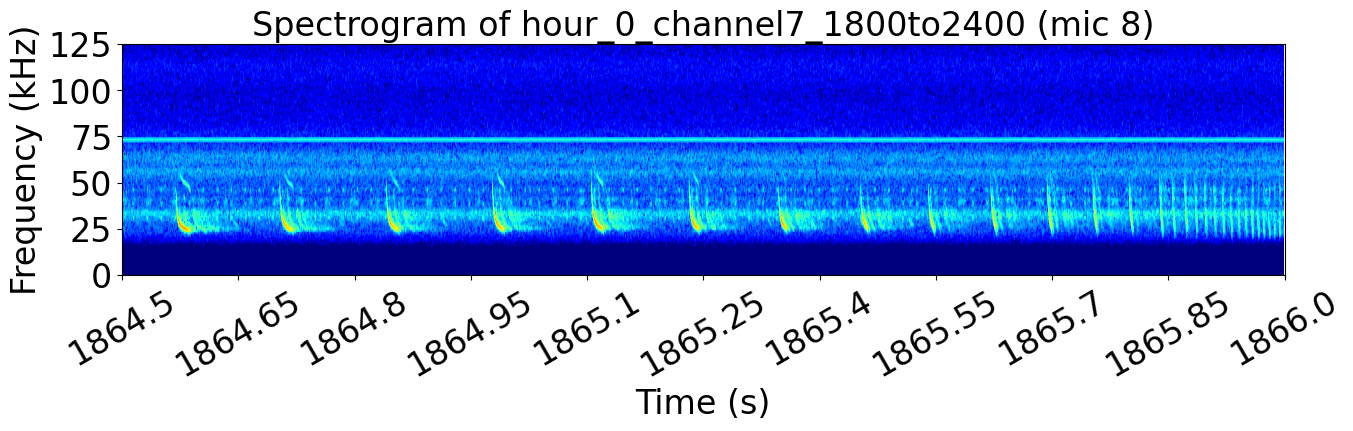

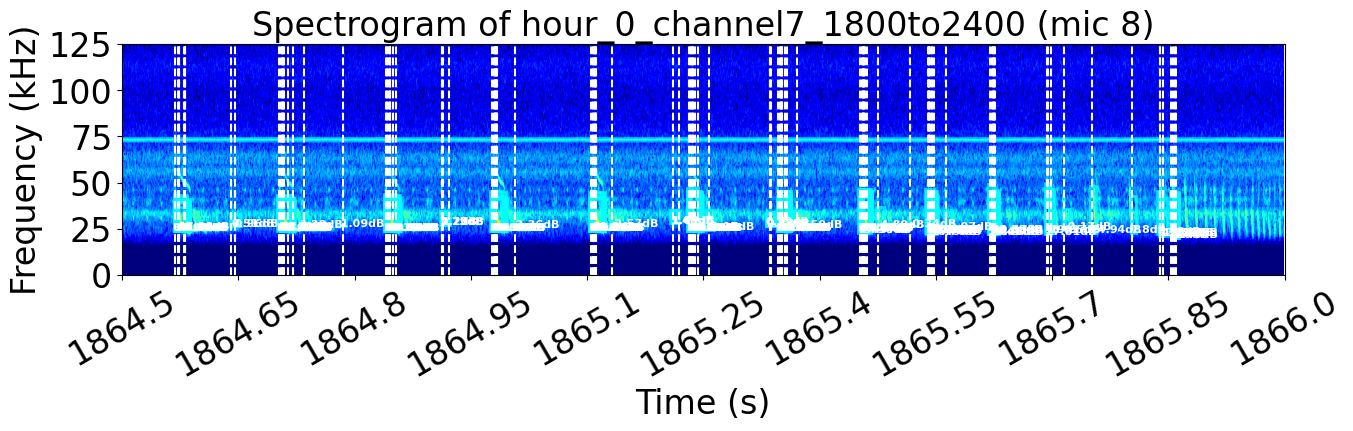

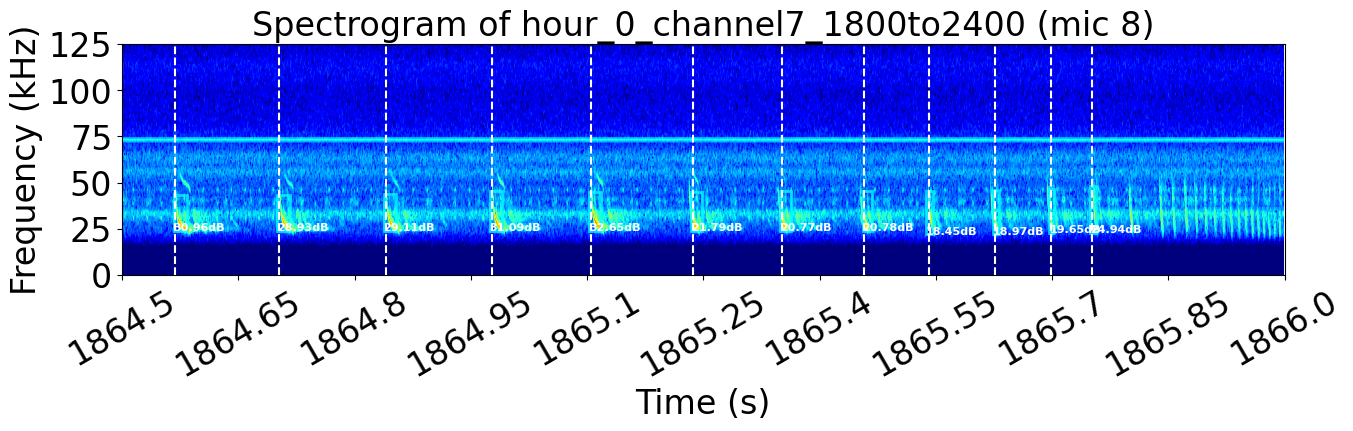

In [128]:
%matplotlib inline

write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

start = 64.5
length = 1.5
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=15].reset_index(drop=True).copy()
plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

In [129]:
plot_channel_dets.iloc[:8,1:-3]

,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,freq_group,call_start_time,cycle_ref_time
6205,64.568168,31250.0,25920.0,30.958897,1864.5665,1864.5832,23750,43511,Nyctalus leisleri,0.339,0.665,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.566500,2025-05-02 04:01:18.566500
6206,64.581044,23437.5,27840.0,28.035895,1864.5675,1864.5833,23750,40551,Nyctalus noctula,0.290,0.632,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.567500,2025-05-02 04:01:18.567500
6207,64.571724,31250.0,25920.0,28.382657,1864.5695,1864.5843,23750,42294,Nyctalus leisleri,0.319,0.631,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.569500,2025-05-02 04:01:18.569500
6208,64.579620,23437.5,25920.0,23.942180,1864.5695,1864.5857,23750,39646,Nyctalus leisleri,0.364,0.595,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.569500,2025-05-02 04:01:18.569500
6209,64.581820,23437.5,25920.0,22.868725,1864.5705,1864.5855,23750,37068,Nyctalus leisleri,0.365,0.609,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.570500,2025-05-02 04:01:18.570500
6210,64.581148,23437.5,25920.0,19.704997,1864.5715,1864.5875,23750,39882,Eptesicus serotinus,0.242,0.588,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.571500,2025-05-02 04:01:18.571500
6211,64.573344,31250.0,25920.0,24.954084,1864.5715,1864.5878,23750,40953,Nyctalus leisleri,0.359,0.627,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.571500,2025-05-02 04:01:18.571500
6212,64.574060,31250.0,25920.0,17.377486,1864.5725,1864.5883,24609,39089,Nyctalus leisleri,0.401,0.641,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.572500,2025-05-02 04:01:18.572500


In [130]:
set_for_tdoa

,KMEANS_CLASSES,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,...,individual,event,sampling_rate,input_file,freq_group,call_start_time,cycle_ref_time,call_end_time,start_time_wrt_ref,end_time_wrt_ref
0,LF,64.568168,31250.0,25920.0,30.958897,1864.5665,1864.5832,23750,43511,Nyctalus leisleri,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.566500000,2025-05-02 04:01:18.566500000,2025-05-02 04:01:18.583200000,1864.5665,1864.5832
1,LF,64.702568,31250.0,32640.0,28.929262,1864.7005,1864.7168,23750,43251,Nyctalus leisleri,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.700500000,2025-05-02 04:01:18.700500000,2025-05-02 04:01:18.716800000,1864.7005,1864.7168
2,LF,64.840204,31250.0,32640.0,29.113740,1864.8375,1864.8535,23750,44020,Eptesicus serotinus,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.837500000,2025-05-02 04:01:18.837500000,2025-05-02 04:01:18.853500000,1864.8375,1864.8535
3,LF,64.977316,31250.0,32640.0,31.087348,1864.9745,1864.9905,23750,45371,Eptesicus serotinus,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:18.974500000,2025-05-02 04:01:18.974500000,2025-05-02 04:01:18.990500000,1864.9745,1864.9905
4,LF,65.105056,31250.0,32640.0,32.645393,1865.1025,1865.1182,23750,44991,Eptesicus serotinus,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:19.102500000,2025-05-02 04:01:19.102500000,2025-05-02 04:01:19.118200000,1865.1025,1865.1182
5,LF,65.237112,31250.0,33600.0,21.793516,1865.2345,1865.2488,23750,44755,Eptesicus serotinus,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:19.234500000,2025-05-02 04:01:19.234500000,2025-05-02 04:01:19.248800000,1865.2345,1865.2488
6,LF,65.352040,31250.0,32640.0,20.768035,1865.3495,1865.3632,23750,45234,Eptesicus serotinus,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:19.349500000,2025-05-02 04:01:19.349500000,2025-05-02 04:01:19.363200000,1865.3495,1865.3632
7,LF,65.458020,31250.0,32640.0,20.784967,1865.4555,1865.4681,23750,45405,Eptesicus serotinus,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:19.455500000,2025-05-02 04:01:19.455500000,2025-05-02 04:01:19.468100000,1865.4555,1865.4681
8,LF,65.541456,31250.0,28800.0,18.451526,1865.5375,1865.5462,22031,45363,Nyctalus noctula,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:19.537500000,2025-05-02 04:01:19.537500000,2025-05-02 04:01:19.546200000,1865.5375,1865.5462
9,LF,65.626228,31250.0,33600.0,18.969550,1865.6235,1865.6313,22031,45991,Eptesicus serotinus,...,-1,Echolocation,250000,/Volumes/Elements/UBNA_array_tests2025/mic_arr...,LF,2025-05-02 04:01:19.623500000,2025-05-02 04:01:19.623500000,2025-05-02 04:01:19.631300000,1865.6235,1865.6313


In [131]:
def extract_call_starts_for_call(call_segment, approx_call_dur):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(32))
    f, t, Sxx = scipy.signal.spectrogram(call_segment, FS, detrend=False,
                                nfft=32, 
                                window=mpl_specgram_window)
    plt_Sxx = 10*np.log10(Sxx)
    max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
    max_value_across_bins = Sxx[max_ind]
    peak_freq = f[max_ind[0]]
    peak_freq_time = t[max_ind[1]]

    found_call_dur = int(FS*(approx_call_dur+0.005))
    found_call_start = int(FS*(peak_freq_time[0] - 0.004))
    return found_call_start, found_call_dur

def snr_quality_metric(snrcb, snreb, snrce):
    return abs((snrcb+snreb)/snrce)

In [132]:
def get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal): 

    signal_power_rms = np.sqrt(np.square(snr_call_signal).mean())
    noise_power_rms = np.sqrt(np.square(snr_noise_signal).mean())
    snr = (20 * np.log10(signal_power_rms / noise_power_rms))

    return snr

def get_section_spectrogram(section, spec_features):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
    f, t, Sxx = scipy.signal.spectrogram(section, FS, detrend=False, nperseg=spec_features['NFFT'],
                                nfft=spec_features['NFFT'], 
                                window=mpl_specgram_window, mode='magnitude')
    plt_Sxx = 10*np.log10(Sxx/np.max(Sxx))

    return plt_Sxx, f, t

def clean_section_to_remove_noise(section, max_of_all, spec_features):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
    f, t, Sxx = scipy.signal.spectrogram(section, FS, detrend=False, nperseg=spec_features['NFFT'],
                                nfft=spec_features['NFFT'], 
                                window=mpl_specgram_window, mode='magnitude')
    plt_Sxx = 10*np.log10(Sxx/max_of_all)
    all_maxes_per_bin = np.max(plt_Sxx, axis=0)
    cleaned_plt_Sxx = np.where(plt_Sxx < all_maxes_per_bin - 10, -40, plt_Sxx)

    return cleaned_plt_Sxx, f, t

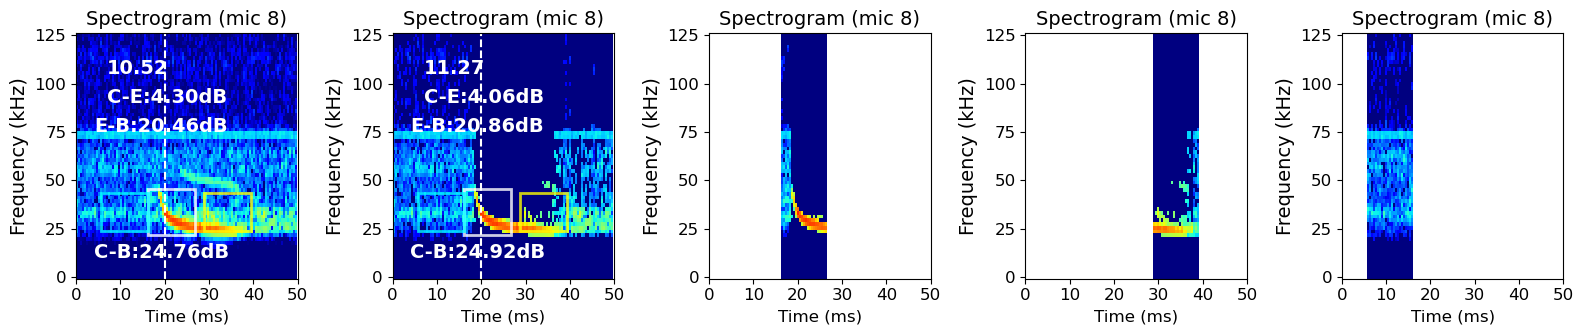

In [133]:
%matplotlib inline

plt.figure(figsize=(16, 3.5))
plt.rcParams.update({'font.size': 12})
selected_channel = 7
i = 0
det = set_for_tdoa.iloc[i]
start = det['start_time'] - file_offset - SNR_OFFSET_BEFORE_CALL
approx_call_dur = localize.get_approx_call_dur(det)
write_file = write_dir / f'{HOUR_TAG}_channel{selected_channel}_{FILE_TIME_TAG}.WAV'

filtered_det = localize.extract_highpassed_detection_from_wavfilepath(write_file, start, SNR_CALC_LENGTH, det)

found_call_start, found_call_dur = extract_call_starts_for_call(filtered_det, approx_call_dur)
found_call_end = (found_call_start+found_call_dur)
echo_pad = int(FS*TIME_PAD_FOR_ECHO)
found_call, found_background, found_echo = localize.extract_approx_call_windows_for_snr_calcs(filtered_det, 
                                                                                        found_call_start, 
                                                                                        found_call_dur)

snrce = localize.get_snr_from_band_limited_signal(found_call, found_echo)
snrcb = localize.get_snr_from_band_limited_signal(found_call, found_background)
snreb = localize.get_snr_from_band_limited_signal(found_echo, found_background)

spec_features = dict()
spec_features['NFFT'] = 128 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = -30
spec_features['vmax'] = 5
mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
f, t, Sxx = scipy.signal.spectrogram(filtered_det, FS, detrend=False, nperseg=spec_features['NFFT'],
                            nfft=spec_features['NFFT'], 
                            window=mpl_specgram_window, mode='magnitude')
plt_Sxx = 10*np.log10(Sxx/np.max(Sxx))
max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
max_value_across_bins = Sxx[max_ind]
peak_freq = f[max_ind[0]]
peak_freq_time = t[max_ind[1]]

cleaned_background, fb_f, fb_t = clean_section_to_remove_noise(found_background, np.max(Sxx), spec_features)
cleaned_det, f, t = clean_section_to_remove_noise(filtered_det, np.max(Sxx), spec_features)
cleaned_found_call, fc_f, fc_t = clean_section_to_remove_noise(found_call, np.max(Sxx), spec_features)
cleaned_echo, fe_f, fe_t = clean_section_to_remove_noise(found_echo, np.max(Sxx), spec_features)

snr_ce = get_snr_from_band_limited_signal(10**(cleaned_found_call/10), 10**(cleaned_echo/10))
snr_cb = get_snr_from_band_limited_signal(10**(cleaned_found_call/10), 10**(cleaned_background/10))
snr_eb = get_snr_from_band_limited_signal(10**(cleaned_echo/10), 10**(cleaned_background/10))

plt.subplot(151)
plt.title(f"Spectrogram (mic {selected_channel+1})", fontsize=14)
plt.pcolormesh(t*1e3, f/1e3, plt_Sxx, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plt.text(x=7,y=90,s=f'C-E:{snrce:.2f}dB',color='w',fontsize=14, fontweight='bold')
plt.text(x=4,y=10,s=f'C-B:{snrcb:.2f}dB',color='w',fontsize=14, fontweight='bold')
plt.text(x=4,y=75,s=f'E-B:{snreb:.2f}dB',color='w',fontsize=14, fontweight='bold')
plt.text(x=7,y=105,s=f'{round(snr_quality_metric(snrcb, snreb, snrce), 3):.2f}',color='w',fontsize=14, fontweight='bold')
plt.axvline(x=1e3*peak_freq_time, color='w', linestyle='dashed')
ax = plt.gca()
rect_call = patches.Rectangle(((found_call_start/FS)*1e3, (det['low_freq']-2000)/1e3), 
                (found_call_dur/FS)*1e3, ((det['high_freq']-det['low_freq'])+4000)/1e3, 
                linewidth=2, edgecolor='white', facecolor='none', alpha=0.8)
ax.add_patch(rect_call)
rect_echo = patches.Rectangle((((found_call_end+echo_pad)/FS)*1e3, det['low_freq']/1e3), 
                ((found_call_dur)/FS)*1e3, (det['high_freq'] - det['low_freq'])/1e3, 
                linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.8)
ax.add_patch(rect_echo)
rect_background = patches.Rectangle((((found_call_start-found_call_dur)/FS)*1e3, det['low_freq']/1e3), 
                ((found_call_dur)/FS)*1e3, (det['high_freq'] - det['low_freq'])/1e3, 
                linewidth=2, edgecolor='cyan', facecolor='none', alpha=0.8)
ax.add_patch(rect_background)
plt.yticks(np.linspace(0, FS/2e3, 6).astype('int'))
plt.ylabel("Frequency (kHz)", fontsize=14)
plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6), rotation=0)
plt.xlabel("Time (ms)")

plt.subplot(152)
plt.title(f"Spectrogram (mic {selected_channel+1})", fontsize=14)
plt.pcolormesh(t*1e3, f/1e3, cleaned_det, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plt.text(x=7,y=90,s=f'C-E:{snr_ce:.2f}dB',color='w',fontsize=14, fontweight='bold')
plt.text(x=4,y=10,s=f'C-B:{snr_cb:.2f}dB',color='w',fontsize=14, fontweight='bold')
plt.text(x=4,y=75,s=f'E-B:{snr_eb:.2f}dB',color='w',fontsize=14, fontweight='bold')
plt.text(x=7,y=105,s=f'{round(snr_quality_metric(snr_cb, snr_eb, snr_ce), 3):.2f}',color='w',fontsize=14, fontweight='bold')
plt.axvline(x=1e3*peak_freq_time, color='w', linestyle='dashed')
ax = plt.gca()
rect_call = patches.Rectangle(((found_call_start/FS)*1e3, (det['low_freq']-2000)/1e3), 
                (found_call_dur/FS)*1e3, ((det['high_freq']-det['low_freq'])+4000)/1e3, 
                linewidth=2, edgecolor='white', facecolor='none', alpha=0.8)
ax.add_patch(rect_call)
rect_echo = patches.Rectangle((((found_call_end+echo_pad)/FS)*1e3, det['low_freq']/1e3), 
                ((found_call_dur)/FS)*1e3, (det['high_freq'] - det['low_freq'])/1e3, 
                linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.8)
ax.add_patch(rect_echo)
rect_background = patches.Rectangle((((found_call_start-found_call_dur)/FS)*1e3, det['low_freq']/1e3), 
                ((found_call_dur)/FS)*1e3, (det['high_freq'] - det['low_freq'])/1e3, 
                linewidth=2, edgecolor='cyan', facecolor='none', alpha=0.8)
ax.add_patch(rect_background)
plt.yticks(np.linspace(0, FS/2e3, 6).astype('int'))
plt.ylabel("Frequency (kHz)", fontsize=14)
plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6), rotation=0)
plt.xlabel("Time (ms)")

plt.subplot(153)
plt.title(f"Spectrogram (mic {selected_channel+1})", fontsize=14)
plt.pcolormesh((fc_t + (found_call_start/FS))*1e3, fc_f/1e3, cleaned_found_call, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plt.yticks(np.linspace(0, FS/2e3, 6).astype('int'))
plt.ylabel("Frequency (kHz)", fontsize=14)
plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6), rotation=0)
plt.xlabel("Time (ms)")

plt.subplot(154)
plt.title(f"Spectrogram (mic {selected_channel+1})", fontsize=14)
plt.pcolormesh((fe_t + (found_call_end/FS) + TIME_PAD_FOR_ECHO)*1e3, fe_f/1e3, cleaned_echo, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plt.yticks(np.linspace(0, FS/2e3, 6).astype('int'))
plt.ylabel("Frequency (kHz)", fontsize=14)
plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6), rotation=0)
plt.xlabel("Time (ms)")

plt.subplot(155)
plt.title(f"Spectrogram (mic {selected_channel+1})", fontsize=14)
plt.pcolormesh((fb_t + ((found_call_start - found_call_dur)/FS))*1e3, fb_f/1e3, cleaned_background, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plt.yticks(np.linspace(0, FS/2e3, 6).astype('int'))
plt.ylabel("Frequency (kHz)", fontsize=14)
plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6), rotation=0)
plt.xlabel("Time (ms)")

plt.tight_layout()
plt.show()

In [134]:
snr_ce = get_snr_from_band_limited_signal(10**(cleaned_found_call/10), 10**(cleaned_echo/10))
snr_cb = get_snr_from_band_limited_signal(10**(cleaned_found_call/10), 10**(cleaned_background/10))
snr_eb = get_snr_from_band_limited_signal(10**(cleaned_echo/10), 10**(cleaned_background/10))


snr_eb, snr_ce, snr_cb, 

(20.863358372277425, 4.061236706301331, 24.924595078578754)

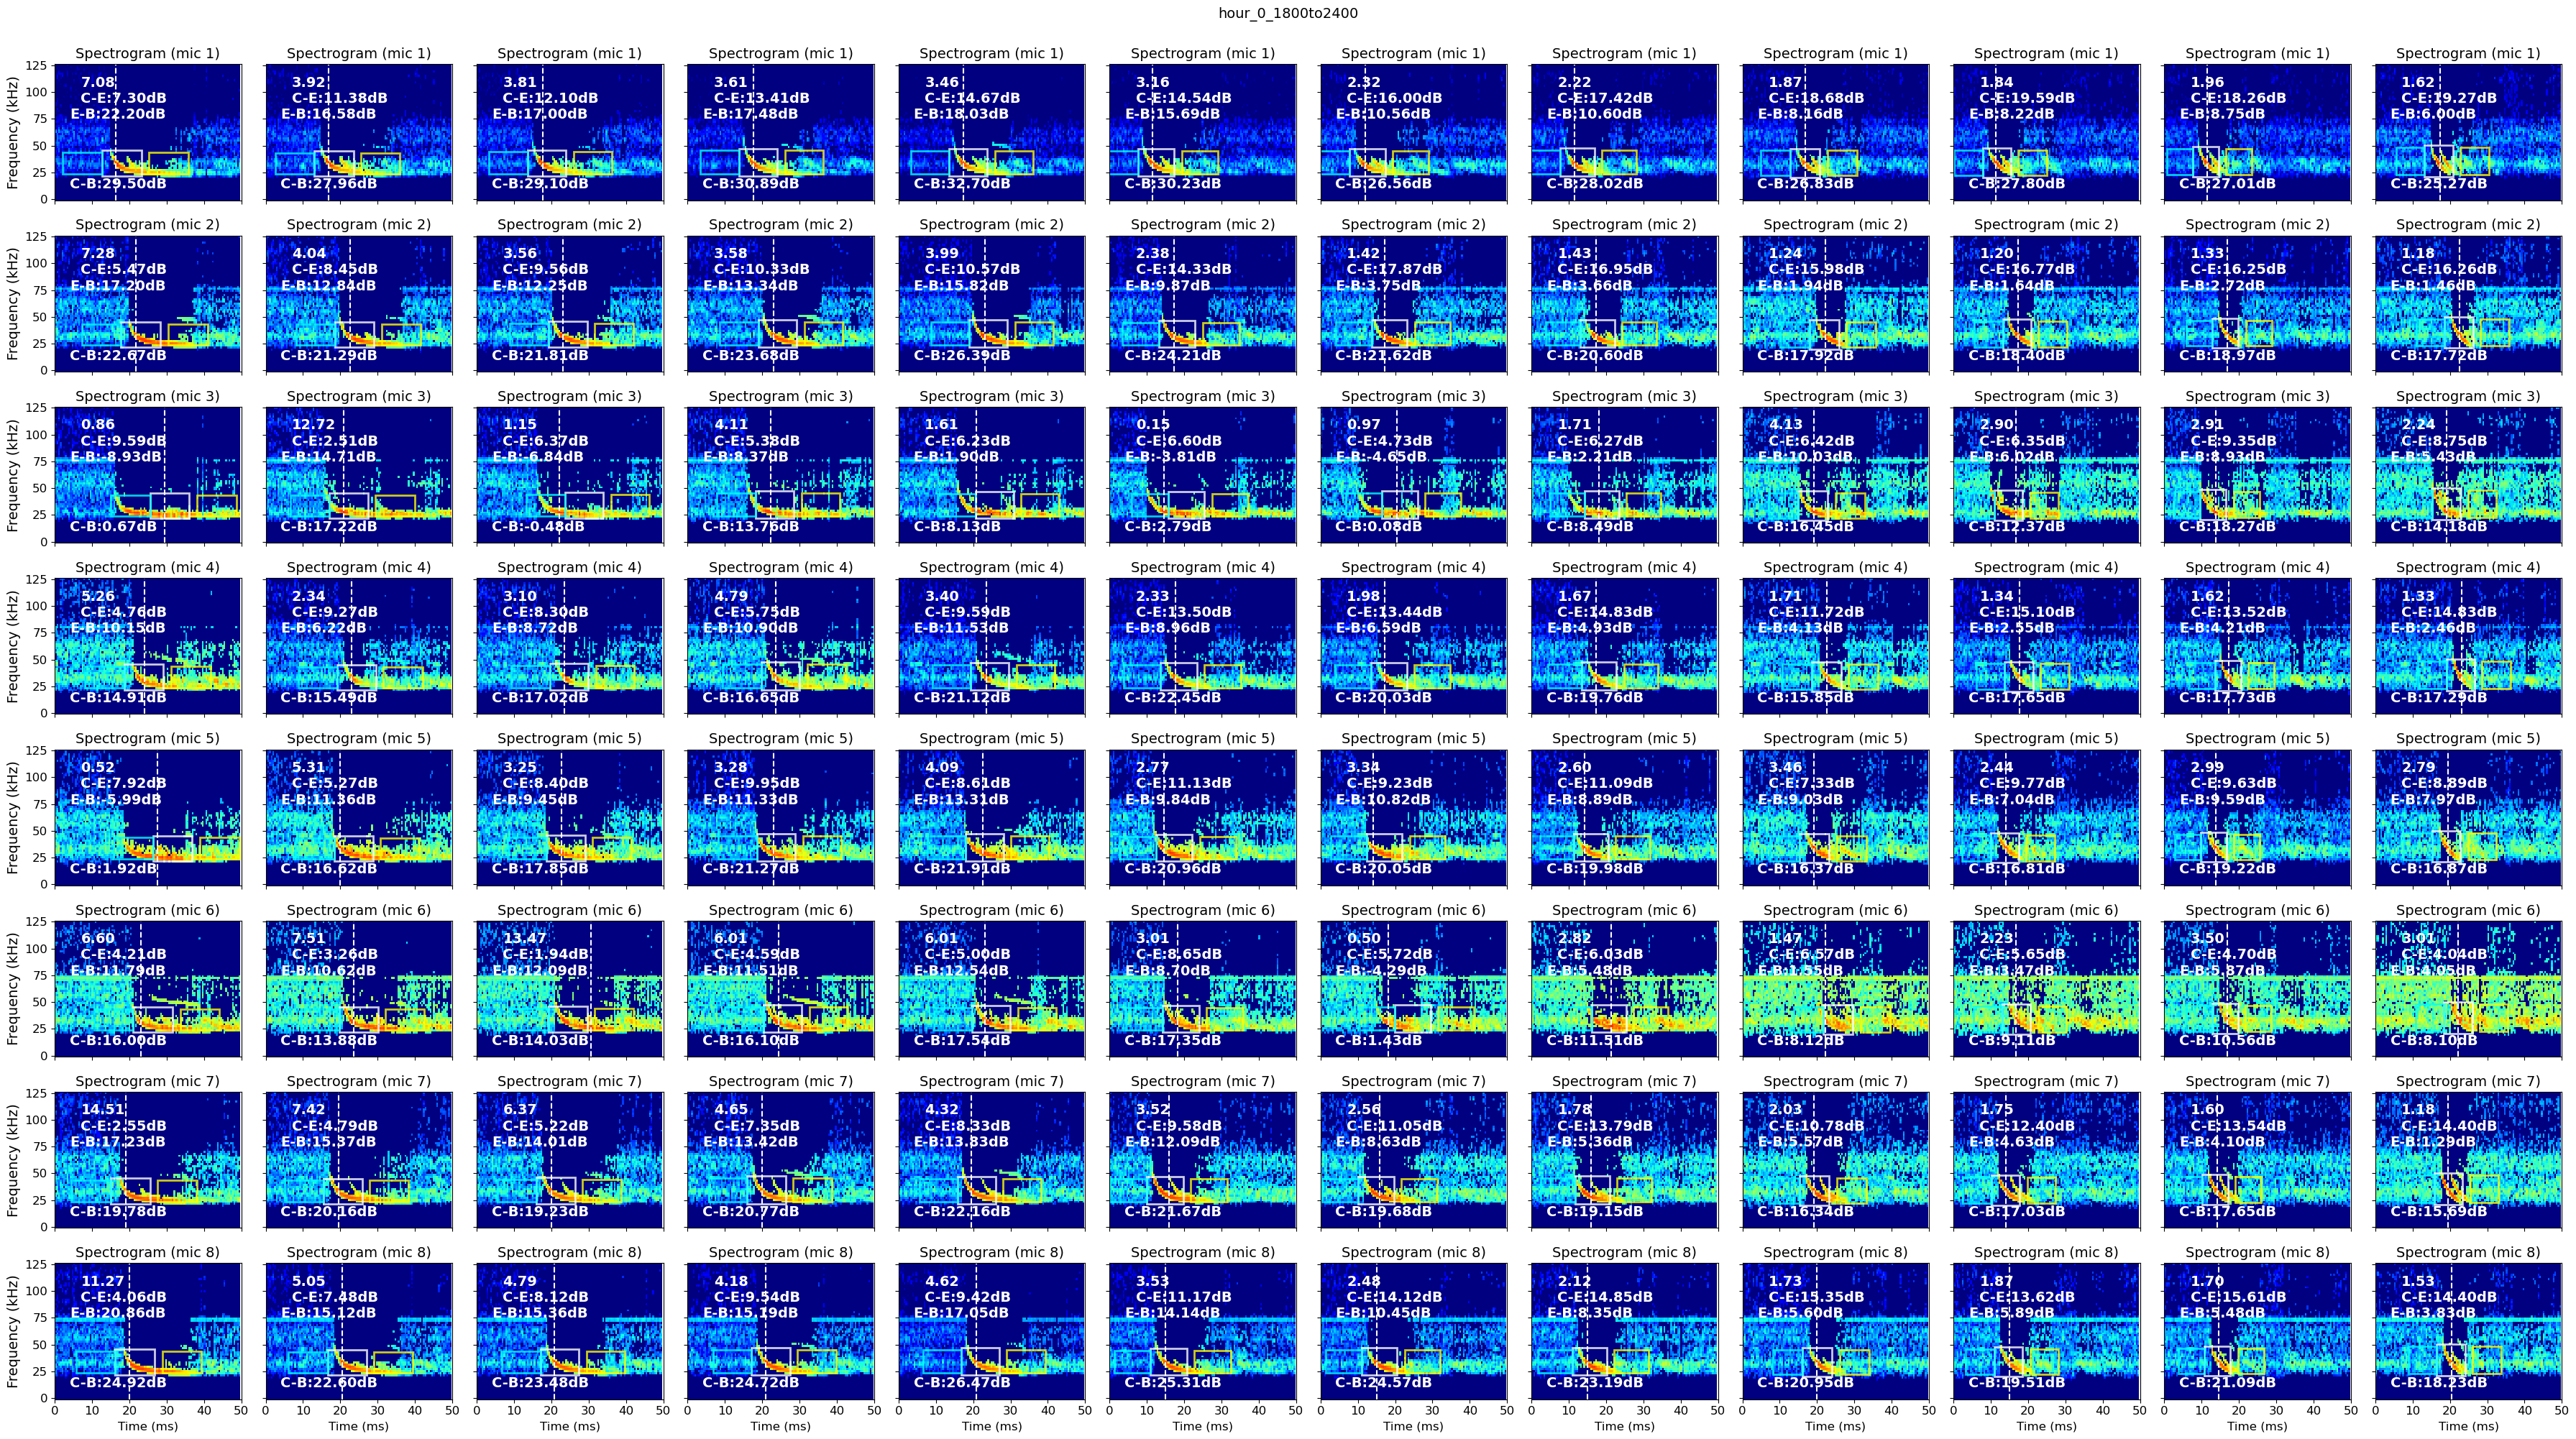

In [135]:
%matplotlib inline

example_calls = np.zeros((set_for_tdoa.shape[0], num_good_channels, int(FS*SNR_CALC_LENGTH)), dtype=np.float64)
example_call_snrs = np.zeros((set_for_tdoa.shape[0], num_good_channels), dtype=np.float64)
example_snr_facs = np.zeros((set_for_tdoa.shape[0], num_good_channels), dtype=np.float64)
example_det_durs = np.zeros(set_for_tdoa.shape[0], dtype=np.float64)
examining_df = set_for_tdoa[::].copy()
call_num = 0
plt.figure(figsize=(3*len(examining_df), 2.5*num_good_channels))
plt.rcParams.update({'font.size': 12})
plt.suptitle(f'{HOUR_TAG}_{FILE_TIME_TAG}', y=1.0, fontsize=14)
channel_num = 0
for selected_channel in (microphones_used-1):
    for i, det in examining_df.iterrows():
        start = det['start_time'] - file_offset - SNR_OFFSET_BEFORE_CALL
        approx_call_dur = localize.get_approx_call_dur(det)
        example_det_durs[i] = approx_call_dur

        write_file = write_dir / f'{HOUR_TAG}_channel{selected_channel}_{FILE_TIME_TAG}.WAV'
        call_num+=1
        
        filtered_det = localize.extract_highpassed_detection_from_wavfilepath(write_file, start, SNR_CALC_LENGTH, det)
        example_calls[i, channel_num,:] = filtered_det

        found_call_start, found_call_dur = extract_call_starts_for_call(filtered_det, approx_call_dur)
        found_call_end = (found_call_start+found_call_dur)
        echo_pad = int(FS*TIME_PAD_FOR_ECHO)
        found_call, found_background, found_echo = localize.extract_approx_call_windows_for_snr_calcs(filtered_det, 
                                                                                                found_call_start, 
                                                                                                found_call_dur)

        spec_features = dict()
        spec_features['NFFT'] = 128 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = -30
        spec_features['vmax'] = 5
        mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
        f, t, Sxx = scipy.signal.spectrogram(filtered_det, FS, detrend=False, nperseg=spec_features['NFFT'],
                                    nfft=spec_features['NFFT'], 
                                    window=mpl_specgram_window, mode='magnitude')
        plt_Sxx = 10*np.log10(Sxx/np.max(Sxx))
        max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
        max_value_across_bins = Sxx[max_ind]
        peak_freq = f[max_ind[0]]
        peak_freq_time = t[max_ind[1]]

        cleaned_background, fb_f, fb_t = clean_section_to_remove_noise(found_background, np.max(Sxx), spec_features)
        cleaned_det, f, t = clean_section_to_remove_noise(filtered_det, np.max(Sxx), spec_features)
        cleaned_found_call, fc_f, fc_t = clean_section_to_remove_noise(found_call, np.max(Sxx), spec_features)
        cleaned_echo, fe_f, fe_t = clean_section_to_remove_noise(found_echo, np.max(Sxx), spec_features)

        snr_ce = get_snr_from_band_limited_signal(10**(cleaned_found_call/10), 10**(cleaned_echo/10))
        snr_cb = get_snr_from_band_limited_signal(10**(cleaned_found_call/10), 10**(cleaned_background/10))
        snr_eb = get_snr_from_band_limited_signal(10**(cleaned_echo/10), 10**(cleaned_background/10))

        plt.subplot(num_good_channels, len(examining_df), call_num)
        plt.rcParams.update({'font.size': 12})
        plt.title(f"Spectrogram (mic {selected_channel+1})", fontsize=14)
        plt.pcolormesh(t*1e3, f/1e3, cleaned_det, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
        plt.text(x=7,y=90,s=f'C-E:{snr_ce:.2f}dB',color='w',fontsize=14, fontweight='bold')
        plt.text(x=4,y=10,s=f'C-B:{snr_cb:.2f}dB',color='w',fontsize=14, fontweight='bold')
        plt.text(x=4,y=75,s=f'E-B:{snr_eb:.2f}dB',color='w',fontsize=14, fontweight='bold')
        plt.text(x=7,y=105,s=f'{round(snr_quality_metric(snr_cb, snr_eb, snr_ce), 3):.2f}',color='w',fontsize=14, fontweight='bold')
        plt.axvline(x=1e3*peak_freq_time, color='w', linestyle='dashed')
        ax = plt.gca()
        rect_call = patches.Rectangle(((found_call_start/FS)*1e3, (det['low_freq']-2000)/1e3), 
                        (found_call_dur/FS)*1e3, ((det['high_freq']-det['low_freq'])+4000)/1e3, 
                        linewidth=2, edgecolor='white', facecolor='none', alpha=0.8)
        ax.add_patch(rect_call)
        rect_echo = patches.Rectangle((((found_call_end+echo_pad)/FS)*1e3, det['low_freq']/1e3), 
                        ((found_call_dur)/FS)*1e3, (det['high_freq'] - det['low_freq'])/1e3, 
                        linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect_echo)
        rect_background = patches.Rectangle((((found_call_start-found_call_dur)/FS)*1e3, det['low_freq']/1e3), 
                        ((found_call_dur)/FS)*1e3, (det['high_freq'] - det['low_freq'])/1e3, 
                        linewidth=2, edgecolor='cyan', facecolor='none', alpha=0.8)
        ax.add_patch(rect_background)
        if i==0:
            plt.yticks(np.linspace(0, FS/2e3, 6).astype('int'))
            plt.ylabel("Frequency (kHz)", fontsize=14)
        else:
            plt.yticks(ticks=np.linspace(0, FS/2e3, 6), labels=['']*6)
        if selected_channel==(microphones_used[-1]-1):
            plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6), rotation=0)
            plt.xlabel("Time (ms)")    
        else:
            plt.xticks(ticks=np.linspace(0, SNR_CALC_LENGTH*1e3, 6), labels=['']*6)
    channel_num+=1

plt.tight_layout()
plt.show()

In [136]:
def extract_reference_call_only(ref_call_segment, approx_call_dur):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(32))
    f, t, Sxx = scipy.signal.spectrogram(ref_call_segment, FS, detrend=False,
                                nfft=32, 
                                window=mpl_specgram_window)
    plt_Sxx = 10*np.log10(Sxx)
    max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
    max_value_across_bins = Sxx[max_ind]
    peak_freq = f[max_ind[0]]
    peak_freq_time = t[max_ind[1]]

    # found_call_dur = int(FS*(min(0.0045, approx_call_dur+0.002)))
    found_call_dur = int(FS*(0.008))
    found_call_start = int(FS*(peak_freq_time[0] - 0.002))
    
    found_call_end = (found_call_start+found_call_dur)
    ref_mic_call_only = ref_call_segment[found_call_start:found_call_end]

    return ref_mic_call_only, found_call_start/FS, found_call_dur/FS


def index_reference_call_based_on_feature_to_maximize(calls, detection_index, feature):
    return calls[detection_index, np.argmax(feature[detection_index]),:], np.argmax(feature[detection_index])

def index_reference_call_based_on_feature_to_minimize(calls, detection_index, feature):
    return calls[detection_index, np.argmin(feature[detection_index]),:], np.argmin(feature[detection_index])

REF_CHANNEL = 7
def index_reference_call_based_on_channel(calls, detection_index, microphones_used, channel):
    ind_of_selected_channel = np.where(microphones_used==(channel+1))[0][0]
    return calls[detection_index, ind_of_selected_channel,:], ind_of_selected_channel

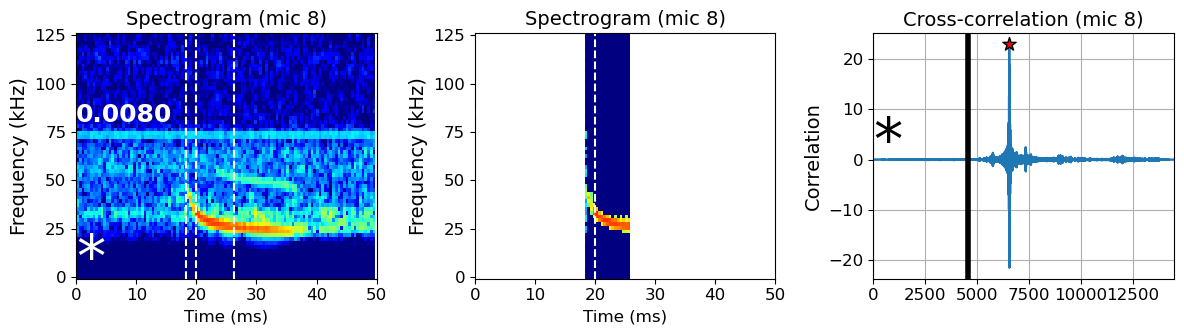

In [137]:
%matplotlib inline

channel_num = 0
plt.figure(figsize=(12, 3.5))
plt.rcParams.update({'font.size': 12})
non_ref_call_i = 7
det_num = 0
nonref_dets = example_calls[det_num]
approx_call_dur = example_det_durs[det_num]
ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(example_calls, det_num, microphones_used, REF_CHANNEL)
# ref_call_of_det, ref_channel_num = index_reference_call_based_on_feature_to_maximize(example_calls, det_num, example_snr_facs)
# ref_call_of_det, ref_channel_num = index_reference_call_based_on_feature_to_minimize(example_calls, det_num, example_snr_facs)
ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)
nonref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(nonref_dets[non_ref_call_i,:], approx_call_dur)

signal1 = nonref_dets[non_ref_call_i, :]
signal2 = ref_mic_call_only

channel_num+=1
spec_features = dict()
spec_features['NFFT'] = 128 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = -30
spec_features['vmax'] = 5
mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
f, t, Sxx = scipy.signal.spectrogram(signal1, FS, detrend=False, nperseg=spec_features['NFFT'],
                            nfft=spec_features['NFFT'], 
                            window=mpl_specgram_window, mode='magnitude')
det_Spec = 10*np.log10(Sxx/np.max(Sxx))
max_ind = np.where(det_Spec==np.max(det_Spec))
max_value_across_bins = Sxx[max_ind]
peak_freq = f[max_ind[0]]
peak_freq_time = t[max_ind[1]]

cleaned_template, fc_f, fc_t = clean_section_to_remove_noise(signal2, np.max(Sxx), spec_features)

snr_ce = get_snr_from_band_limited_signal(10**(cleaned_found_call/10), 10**(cleaned_echo/10))
snr_cb = get_snr_from_band_limited_signal(10**(cleaned_found_call/10), 10**(cleaned_background/10))
snr_eb = get_snr_from_band_limited_signal(10**(cleaned_echo/10), 10**(cleaned_background/10))

correlation = signal.correlate((signal1), (signal2), mode='full')
lags = signal.correlation_lags(len(signal1), len(signal2), mode='full')
max_lag_index = np.argmax(correlation)
time_delay_in_samples = lags[max_lag_index]
time_delay_in_seconds = time_delay_in_samples / FS

plt.subplot(131)
plt.title(f"Spectrogram (mic {microphones_used[non_ref_call_i]})", fontsize=14)
plt.pcolormesh(t*1e3, f/1e3, det_Spec, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plt.axvline(x=peak_freq_time*1e3, color='w', linestyle='dashed')
plt.axvline(x=(found_call_start)*1e3, color='w', linestyle='dashed')
plt.axvline(x=((found_call_start + found_call_dur))*1e3, color='w', linestyle='dashed')
plt.text(x=0,y=80,s=f'{found_call_dur:.4f}', color='w', fontsize=18, fontweight='bold')
if non_ref_call_i==ref_channel_num:
    plt.text(x=0, y=0, s='*', fontsize=42, color='w')
if det_num==0:
    plt.yticks(np.linspace(0, FS/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)", fontsize=14)
else:
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=['']*6)
if non_ref_call_i==(microphones_used[-1]-1):
    plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6).astype(int), rotation=0)
    plt.xlabel("Time (ms)")    
else:
    plt.xticks(ticks=np.linspace(0, SNR_CALC_LENGTH*1e3, 6), labels=['']*6)
plt.xlabel("Time (ms)")   

plt.subplot(132)
plt.title(f"Spectrogram (mic {microphones_used[non_ref_call_i]})", fontsize=14)
plt.pcolormesh((fc_t + found_call_start)*1e3, fc_f/1e3, cleaned_template, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plt.axvline(x=peak_freq_time*1e3, color='w', linestyle='dashed')
plt.axvline(x=(found_call_start)*1e3, color='w', linestyle='dashed')
plt.axvline(x=((found_call_start + found_call_dur))*1e3, color='w', linestyle='dashed')
plt.text(x=0,y=80,s=f'{found_call_dur:.4f}', color='w', fontsize=18, fontweight='bold')
if non_ref_call_i==ref_channel_num:
    plt.text(x=0, y=0, s='*', fontsize=42, color='w')
if det_num==0:
    plt.yticks(np.linspace(0, FS/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)", fontsize=14)
else:
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=['']*6)
if non_ref_call_i==(microphones_used[-1]-1):
    plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6).astype(int), rotation=0)
    plt.xlabel("Time (ms)")    
else:
    plt.xticks(ticks=np.linspace(0, SNR_CALC_LENGTH*1e3, 6), labels=['']*6)
plt.xlabel("Time (ms)")

plt.subplot(133)
plt.title(f"Cross-correlation (mic {microphones_used[non_ref_call_i]})", fontsize=14)
plt.plot(correlation)
plt.scatter(max_lag_index, correlation[max_lag_index], marker='*', s=100, facecolor='r', edgecolor='k', zorder=2)
if non_ref_call_i==ref_channel_num:
    plt.text(x=0, y=0, s='*', fontsize=42)
plt.axvline(x=time_delay_in_samples, linewidth=4, color='k')
plt.ylabel("Correlation", fontsize=14)
plt.grid(which='both')
plt.xlim(0, len(lags))

plt.tight_layout()
plt.show()

In [138]:
det_Spec_lin = 10**(det_Spec/10)
tmpl_lin     = 10**(cleaned_template/10)

xcorr = scipy.signal.correlate2d(det_Spec_lin,              # “image”
                                tmpl_lin,                   # “kernel”
                                mode='valid',               # ≙ only positions where the kernel fits fully
                                boundary='fill')            # zero-pad outside edges (default)

corr_vs_shift = xcorr[0]                                    # 1-D array length 86
best_shift = int(np.argmax(corr_vs_shift))                  # 0-based column where match is best

print(f'best horizontal offset = {best_shift}  (template starts at col {best_shift})')

best horizontal offset = 41  (template starts at col 41)


Text(0.5, 0, 'Time (ms)')

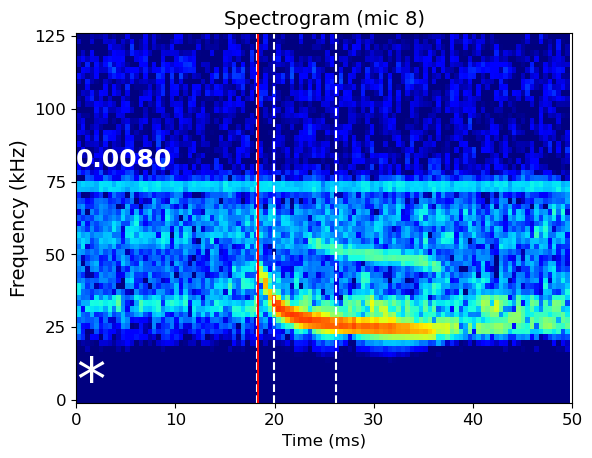

In [139]:
plt.title(f"Spectrogram (mic {microphones_used[non_ref_call_i]})", fontsize=14)
plt.pcolormesh(t*1e3, f/1e3, det_Spec, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plt.axvline(x=peak_freq_time*1e3, color='w', linestyle='dashed')
plt.axvline(x=(found_call_start)*1e3, color='w', linestyle='dashed')
plt.axvline(x=((found_call_start + found_call_dur))*1e3, color='w', linestyle='dashed')
plt.text(x=0,y=80,s=f'{found_call_dur:.4f}', color='w', fontsize=18, fontweight='bold')
plt.axvline(x=(best_shift * (112/FS))*1e3, color='r')
if non_ref_call_i==ref_channel_num:
    plt.text(x=0, y=0, s='*', fontsize=42, color='w')
if det_num==0:
    plt.yticks(np.linspace(0, FS/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)", fontsize=14)
else:
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=['']*6)
if non_ref_call_i==(microphones_used[-1]-1):
    plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6).astype(int), rotation=0)
    plt.xlabel("Time (ms)")    
else:
    plt.xticks(ticks=np.linspace(0, SNR_CALC_LENGTH*1e3, 6), labels=['']*6)
plt.xlabel("Time (ms)")

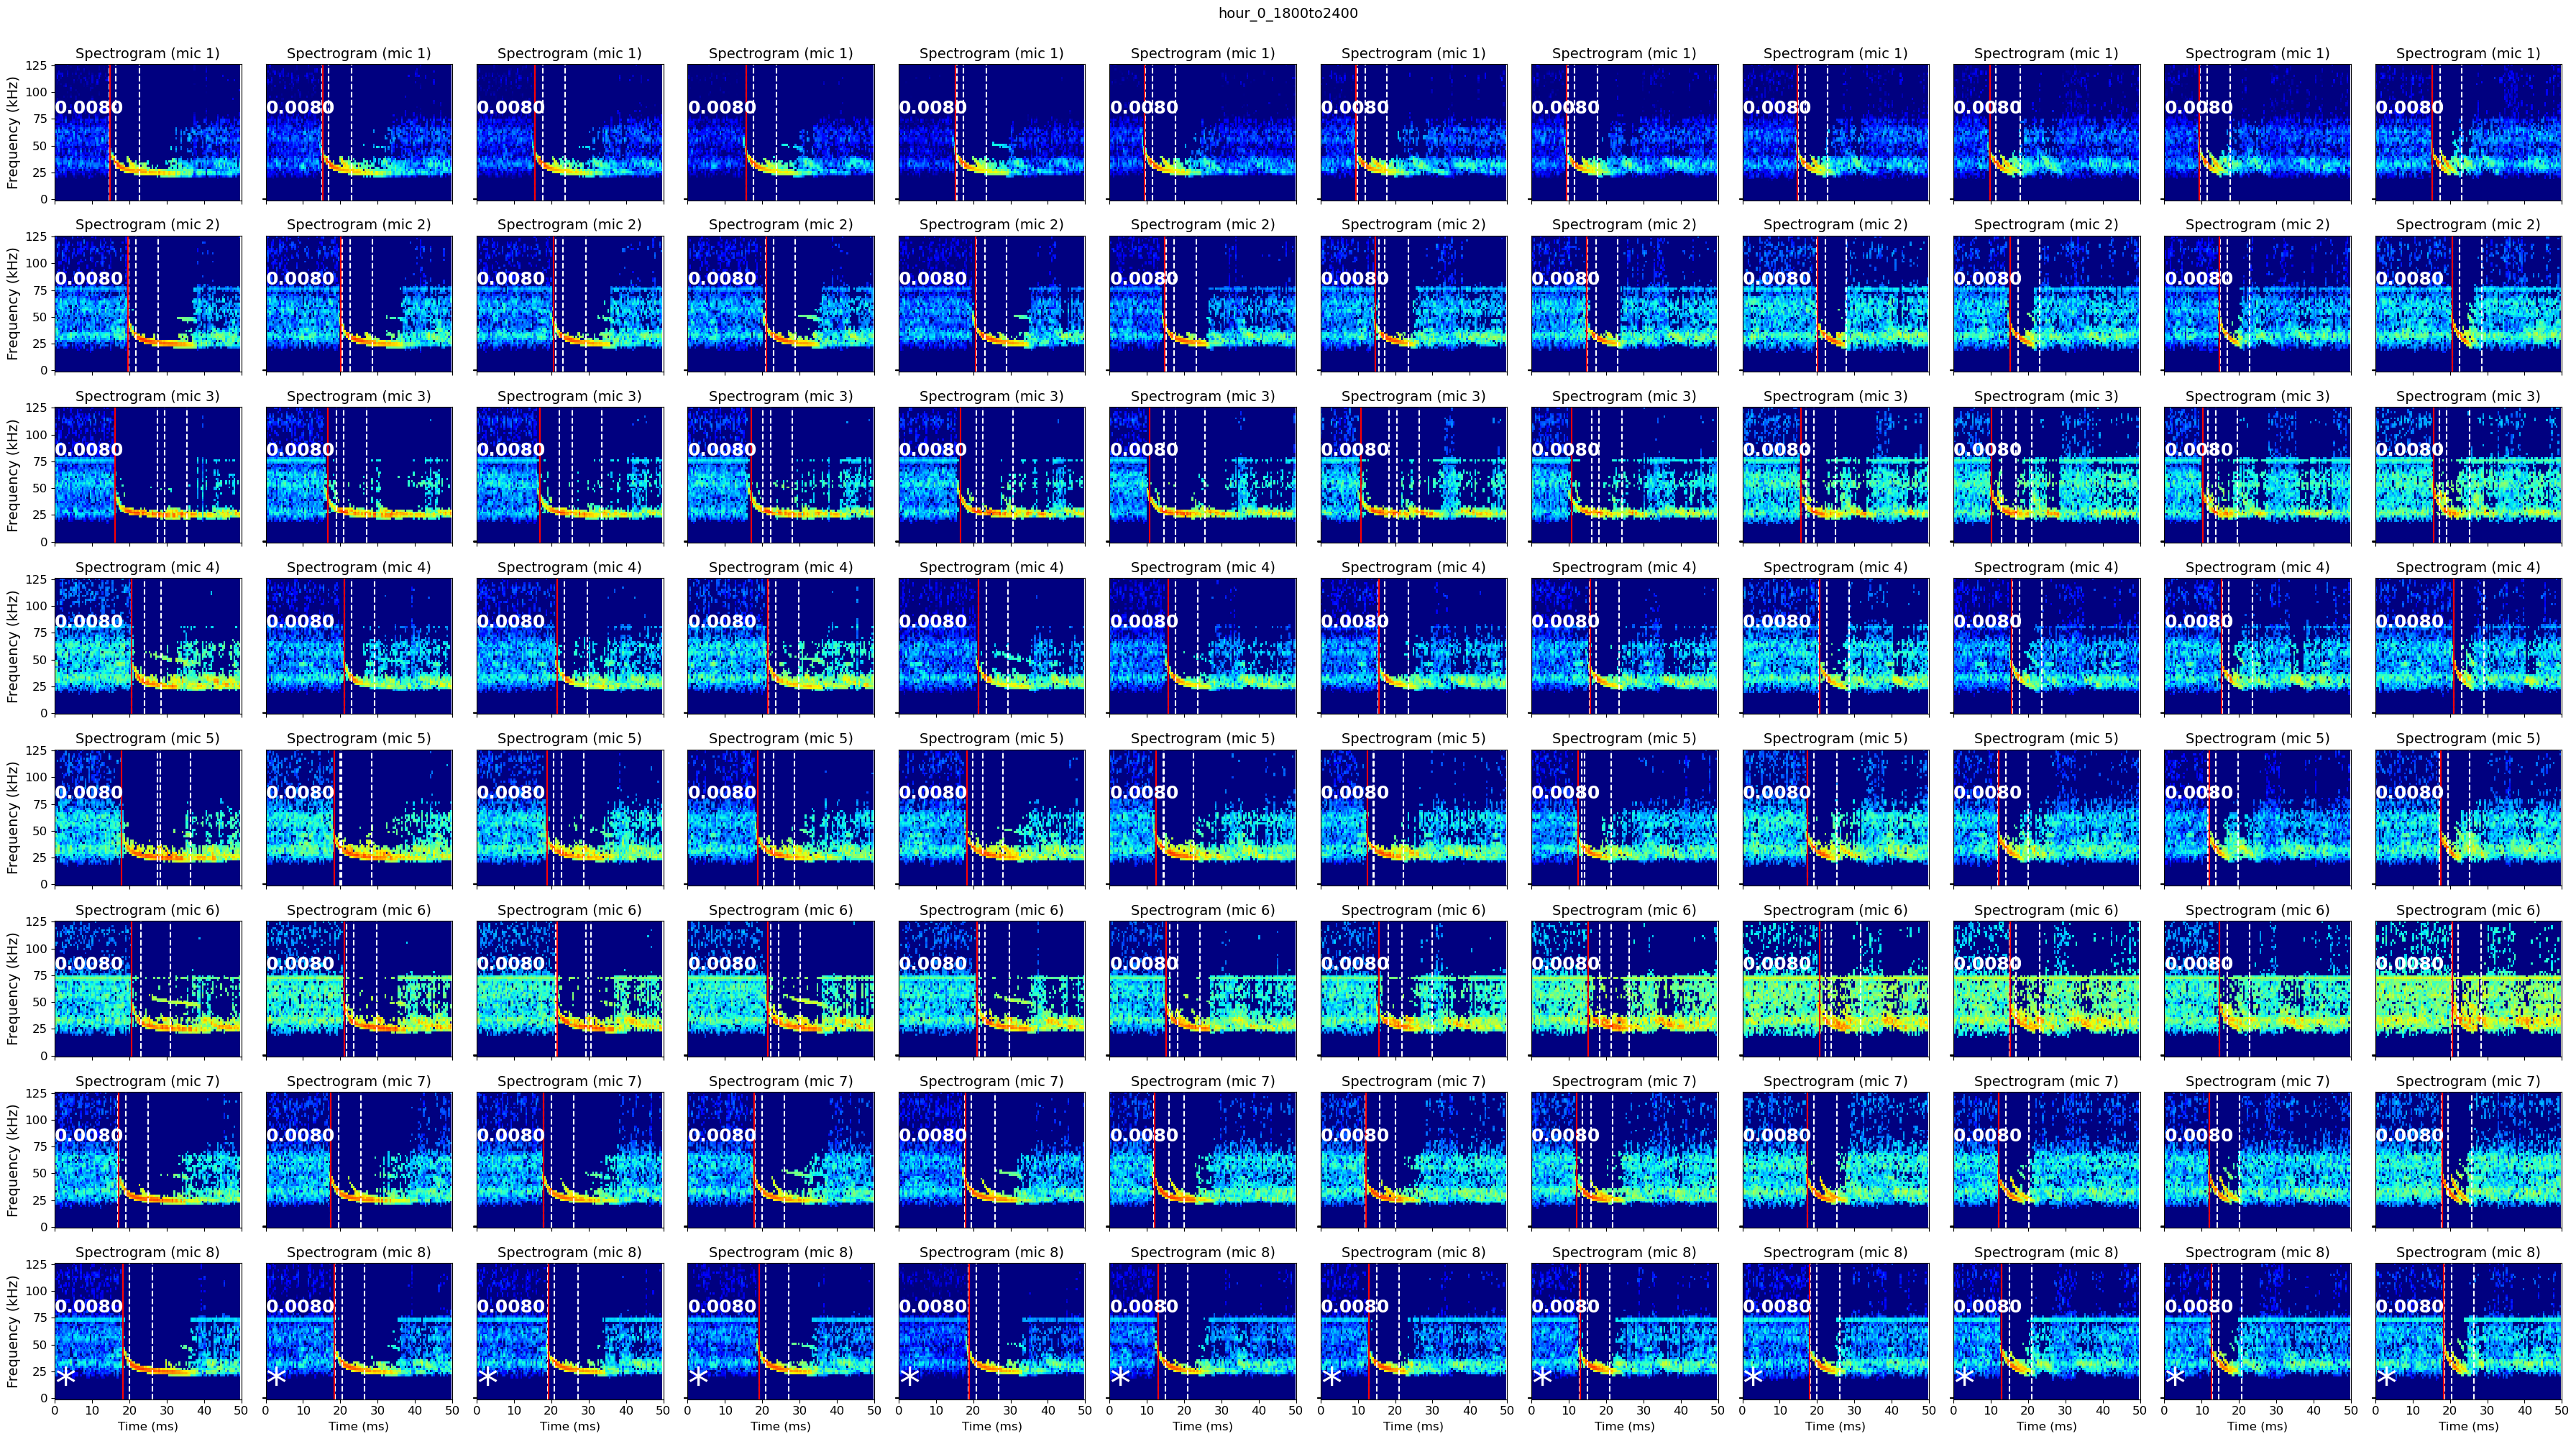

In [140]:
%matplotlib inline

channel_num = 0
plt.figure(figsize=(3*(example_calls.shape[0]), 2.5*num_good_channels))
plt.rcParams.update({'font.size': 12})
plt.suptitle(f'{HOUR_TAG}_{FILE_TIME_TAG}', y=1.0, fontsize=14)
for non_ref_call_i in range(num_good_channels):
    for det_num in range(example_calls.shape[0]):
        nonref_dets = example_calls[det_num]
        approx_call_dur = example_det_durs[det_num]
        ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(example_calls, det_num, microphones_used, REF_CHANNEL)
        # ref_call_of_det, ref_channel_num = index_reference_call_based_on_feature_to_maximize(example_calls, det_num, example_snr_facs)
        # ref_call_of_det, ref_channel_num = index_reference_call_based_on_feature_to_minimize(example_calls, det_num, example_snr_facs)
        ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)
        nonref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(nonref_dets[non_ref_call_i,:], approx_call_dur)

        signal1 = nonref_dets[non_ref_call_i, :]
        signal2 = ref_mic_call_only

        channel_num+=1
        spec_features = dict()
        spec_features['NFFT'] = 128 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = -30
        spec_features['vmax'] = 5
        mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
        f, t, Sxx = scipy.signal.spectrogram(signal1, FS, detrend=False, nperseg=spec_features['NFFT'],
                                    nfft=spec_features['NFFT'], 
                                    window=mpl_specgram_window, mode='magnitude')
        cleaned_det, f, t = clean_section_to_remove_noise(signal1, np.max(Sxx), spec_features)
        cleaned_template, fc_f, fc_t = clean_section_to_remove_noise(signal2, np.max(Sxx), spec_features)
        max_ind = np.where(cleaned_det==np.max(cleaned_det))
        max_value_across_bins = Sxx[max_ind]
        peak_freq = f[max_ind[0]]
        peak_freq_time = t[max_ind[1]]

        det_Spec_lin = 10**(cleaned_det/10)
        tmpl_lin = 10**(cleaned_template/10)
        xcorr = scipy.signal.correlate2d(det_Spec_lin, tmpl_lin, mode='valid', boundary='fill')
        corr_vs_shift = xcorr[0]
        best_shift = int(np.argmax(corr_vs_shift)) 
        time_delay_in_samples = (spec_features['NFFT'] - (spec_features['NFFT']//8)) * best_shift
        time_delay_in_seconds = time_delay_in_samples / FS

        plt.subplot(num_good_channels, example_calls.shape[0], channel_num)
        plt.title(f"Spectrogram (mic {microphones_used[non_ref_call_i]})", fontsize=14)
        plt.pcolormesh(t*1e3, f/1e3, cleaned_det, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
        plt.axvline(x=peak_freq_time*1e3, color='w', linestyle='dashed')
        plt.axvline(x=(found_call_start)*1e3, color='w', linestyle='dashed')
        plt.axvline(x=((found_call_start + found_call_dur))*1e3, color='w', linestyle='dashed')
        plt.axvline(x=time_delay_in_seconds*1e3, color='r')
        plt.text(x=0,y=80,s=f'{found_call_dur:.4f}', color='w', fontsize=18, fontweight='bold')
        if non_ref_call_i==ref_channel_num:
            plt.text(x=0, y=0, s='*', fontsize=42, color='w')
        if det_num==0:
            plt.yticks(np.linspace(0, FS/2000, 6).astype('int'))
            plt.ylabel("Frequency (kHz)", fontsize=14)
        else:
            plt.yticks(ticks=np.linspace(0, 1, 6), labels=['']*6)
        if non_ref_call_i==(microphones_used[-1]-1):
            plt.xticks(np.linspace(0, SNR_CALC_LENGTH*1e3, 6).astype(int), rotation=0)
            plt.xlabel("Time (ms)")    
        else:
            plt.xticks(ticks=np.linspace(0, SNR_CALC_LENGTH*1e3, 6), labels=['']*6)

plt.xlabel("Time (ms)")    
plt.tight_layout()
plt.show()

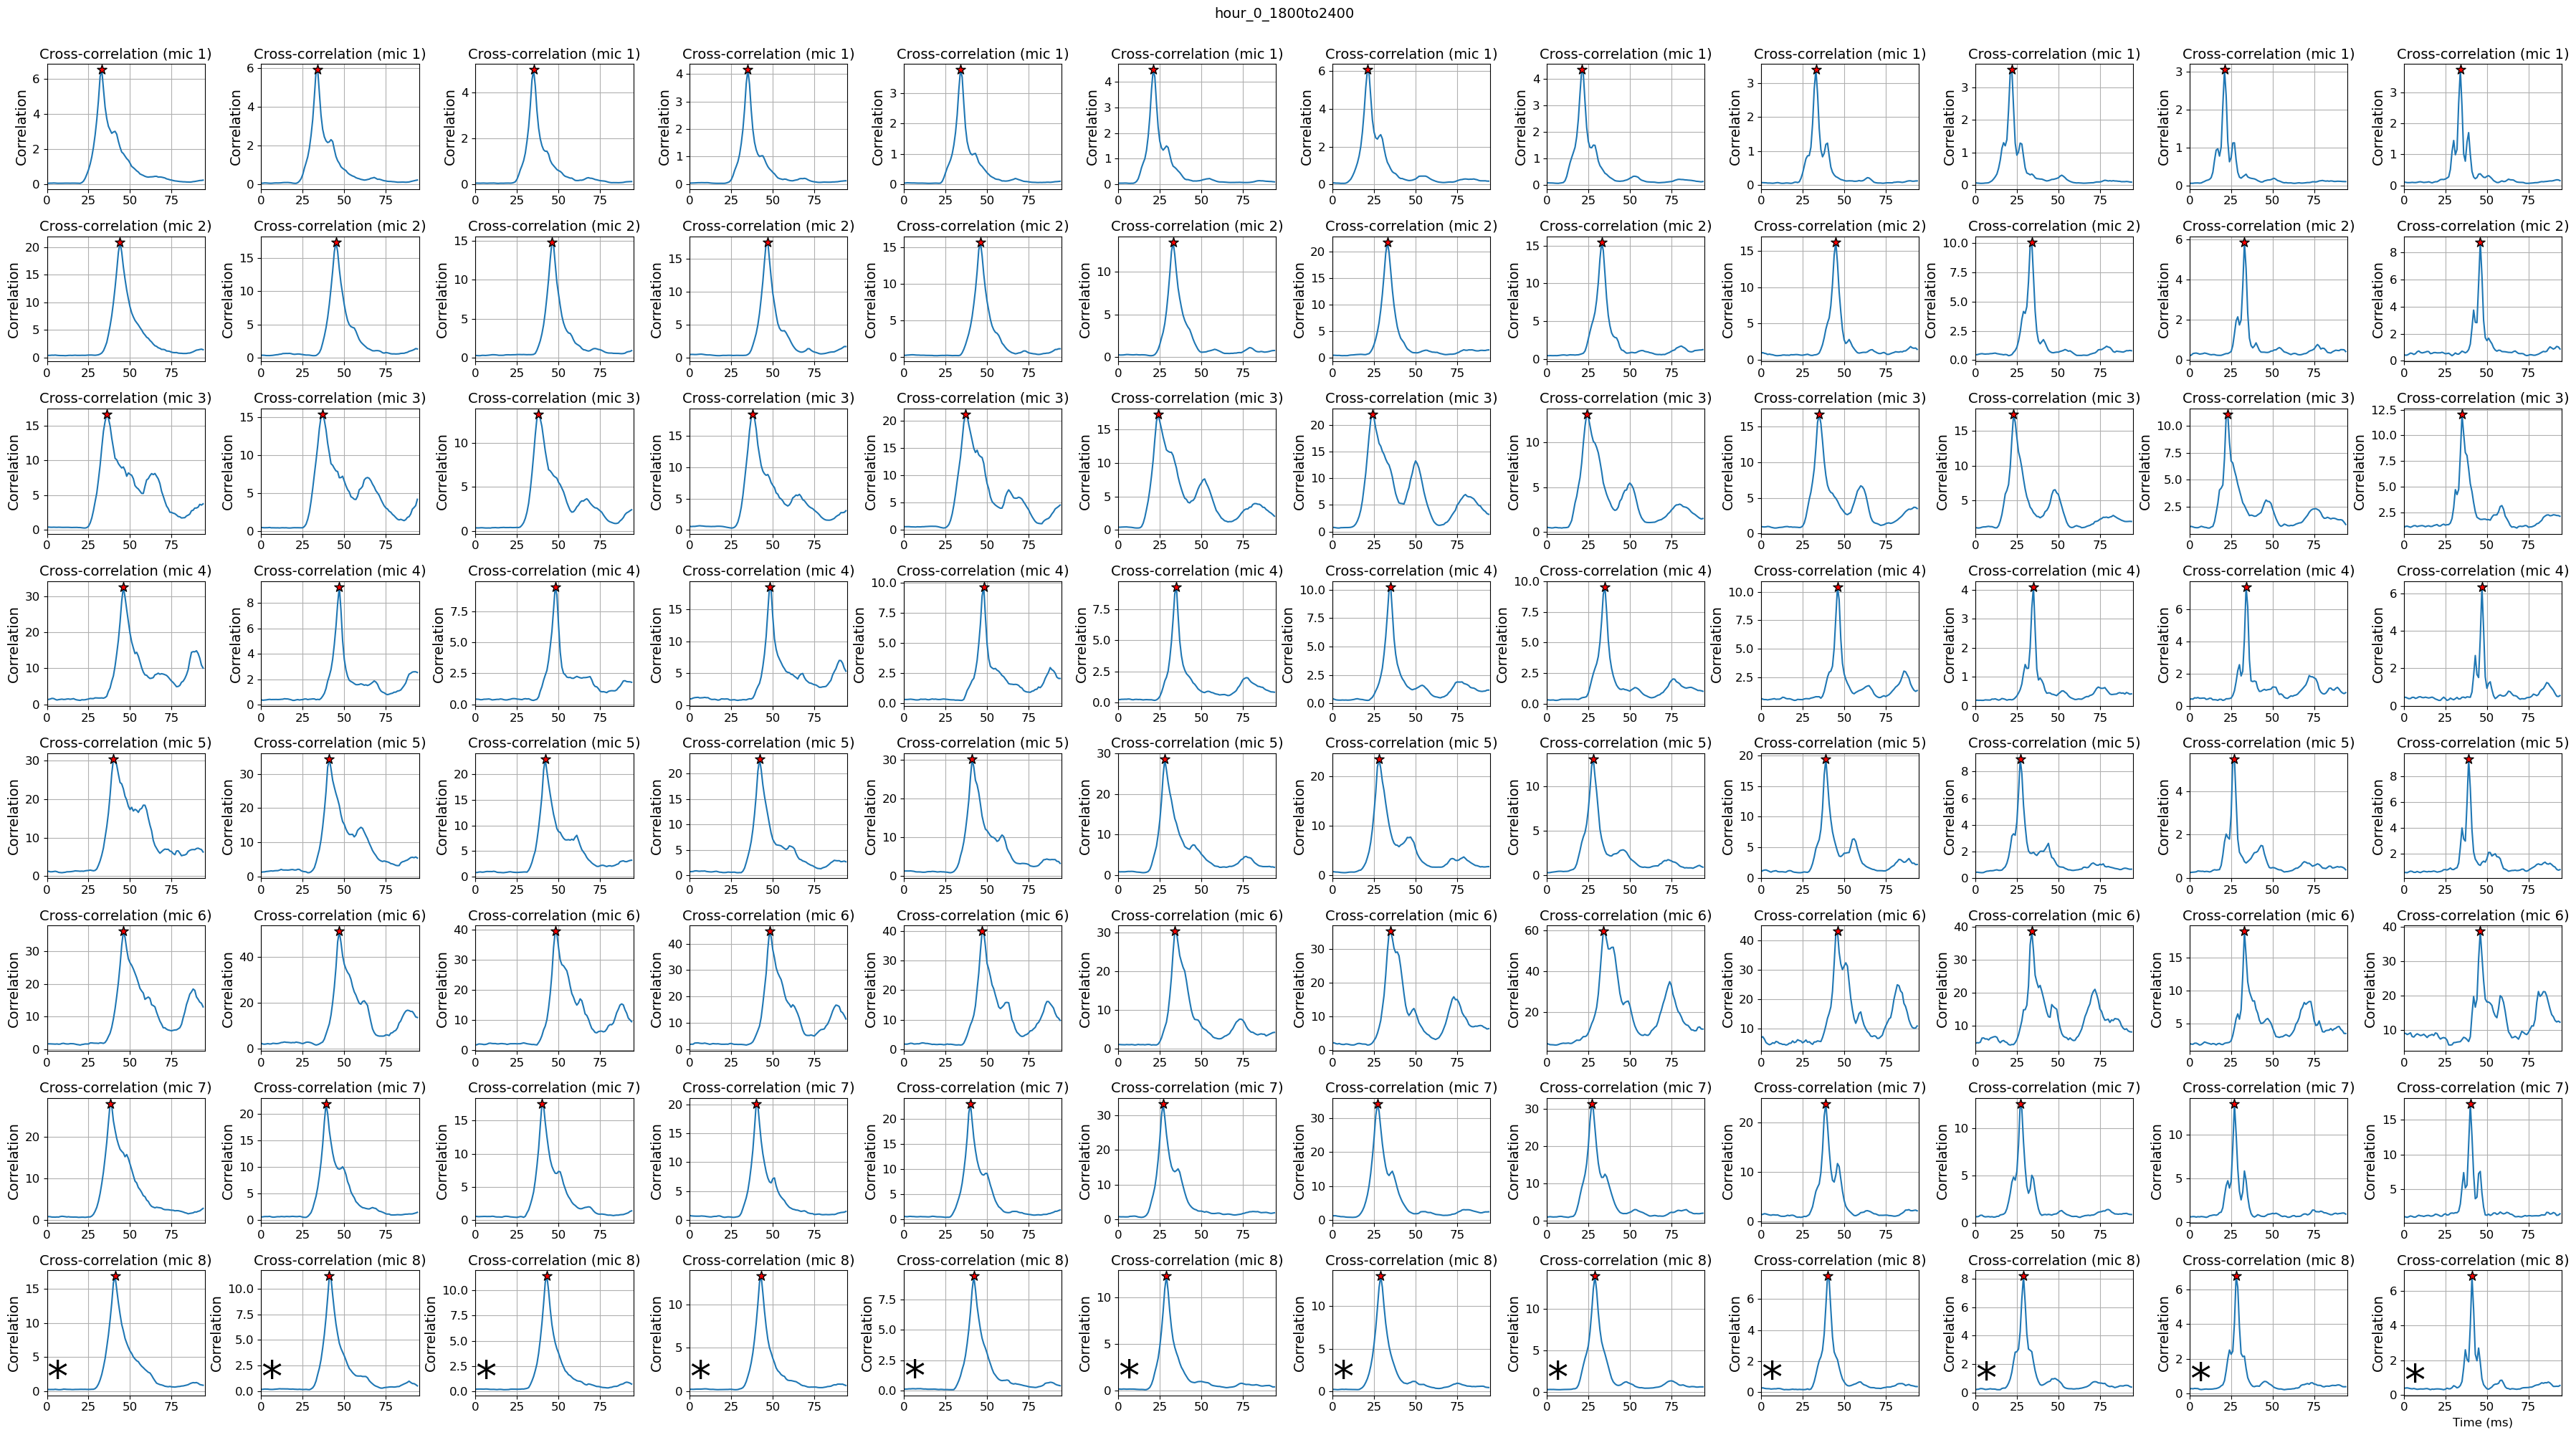

In [141]:
%matplotlib inline

channel_num = 0
plt.figure(figsize=(3*(example_calls.shape[0]), 2.5*num_good_channels))
plt.rcParams.update({'font.size': 12})
plt.suptitle(f'{HOUR_TAG}_{FILE_TIME_TAG}', y=1.0, fontsize=14)
for non_ref_call_i in range(num_good_channels):
    for det_num in range(example_calls.shape[0]):
        nonref_dets = example_calls[det_num]
        approx_call_dur = example_det_durs[det_num]
        ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(example_calls, det_num, microphones_used, REF_CHANNEL)
        # ref_call_of_det, ref_channel_num = index_reference_call_based_on_feature_to_maximize(example_calls, det_num, example_snr_facs)
        # ref_call_of_det, ref_channel_num = index_reference_call_based_on_feature_to_minimize(example_calls, det_num, example_snr_facs)
        ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)

        signal1 = nonref_dets[non_ref_call_i, :]
        signal2 = ref_mic_call_only

        channel_num+=1
        spec_features = dict()
        spec_features['NFFT'] = 128 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = -30
        spec_features['vmax'] = 5
        mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
        f, t, Sxx = scipy.signal.spectrogram(signal1, FS, detrend=False, nperseg=spec_features['NFFT'],
                                    nfft=spec_features['NFFT'], 
                                    window=mpl_specgram_window, mode='magnitude')
        cleaned_det, f, t = clean_section_to_remove_noise(signal1, np.max(Sxx), spec_features)
        cleaned_template, fc_f, fc_t = clean_section_to_remove_noise(signal2, np.max(Sxx), spec_features)
        max_ind = np.where(cleaned_det==np.max(cleaned_det))
        max_value_across_bins = Sxx[max_ind]
        peak_freq = f[max_ind[0]]
        peak_freq_time = t[max_ind[1]]

        det_Spec_lin = 10**(cleaned_det/10)
        tmpl_lin = 10**(cleaned_template/10)
        xcorr = scipy.signal.correlate2d(det_Spec_lin, tmpl_lin, mode='valid', boundary='fill')
        corr_vs_shift = xcorr[0]
        best_shift = int(np.argmax(corr_vs_shift)) 
        time_delay_in_samples = (spec_features['NFFT'] - (spec_features['NFFT']//8)) * best_shift
        time_delay_in_seconds = time_delay_in_samples / FS

        plt.subplot(num_good_channels, example_calls.shape[0], channel_num)
        plt.rcParams.update({'font.size': 12})
        plt.title(f"Cross-correlation (mic {microphones_used[non_ref_call_i]})", fontsize=14)
        plt.plot(corr_vs_shift)
        plt.scatter(best_shift, corr_vs_shift[best_shift], marker='*', s=100, facecolor='r', edgecolor='k', zorder=2)
        if non_ref_call_i==ref_channel_num:
            plt.text(x=0, y=0, s='*', fontsize=42)
        # plt.axvline(x=time_delay_in_samples, linewidth=4, color='k')
        plt.ylabel("Correlation", fontsize=14)
        plt.grid(which='both')
        plt.xlim(0, len(corr_vs_shift))

plt.xlabel("Time (ms)")    
plt.tight_layout()
plt.show()

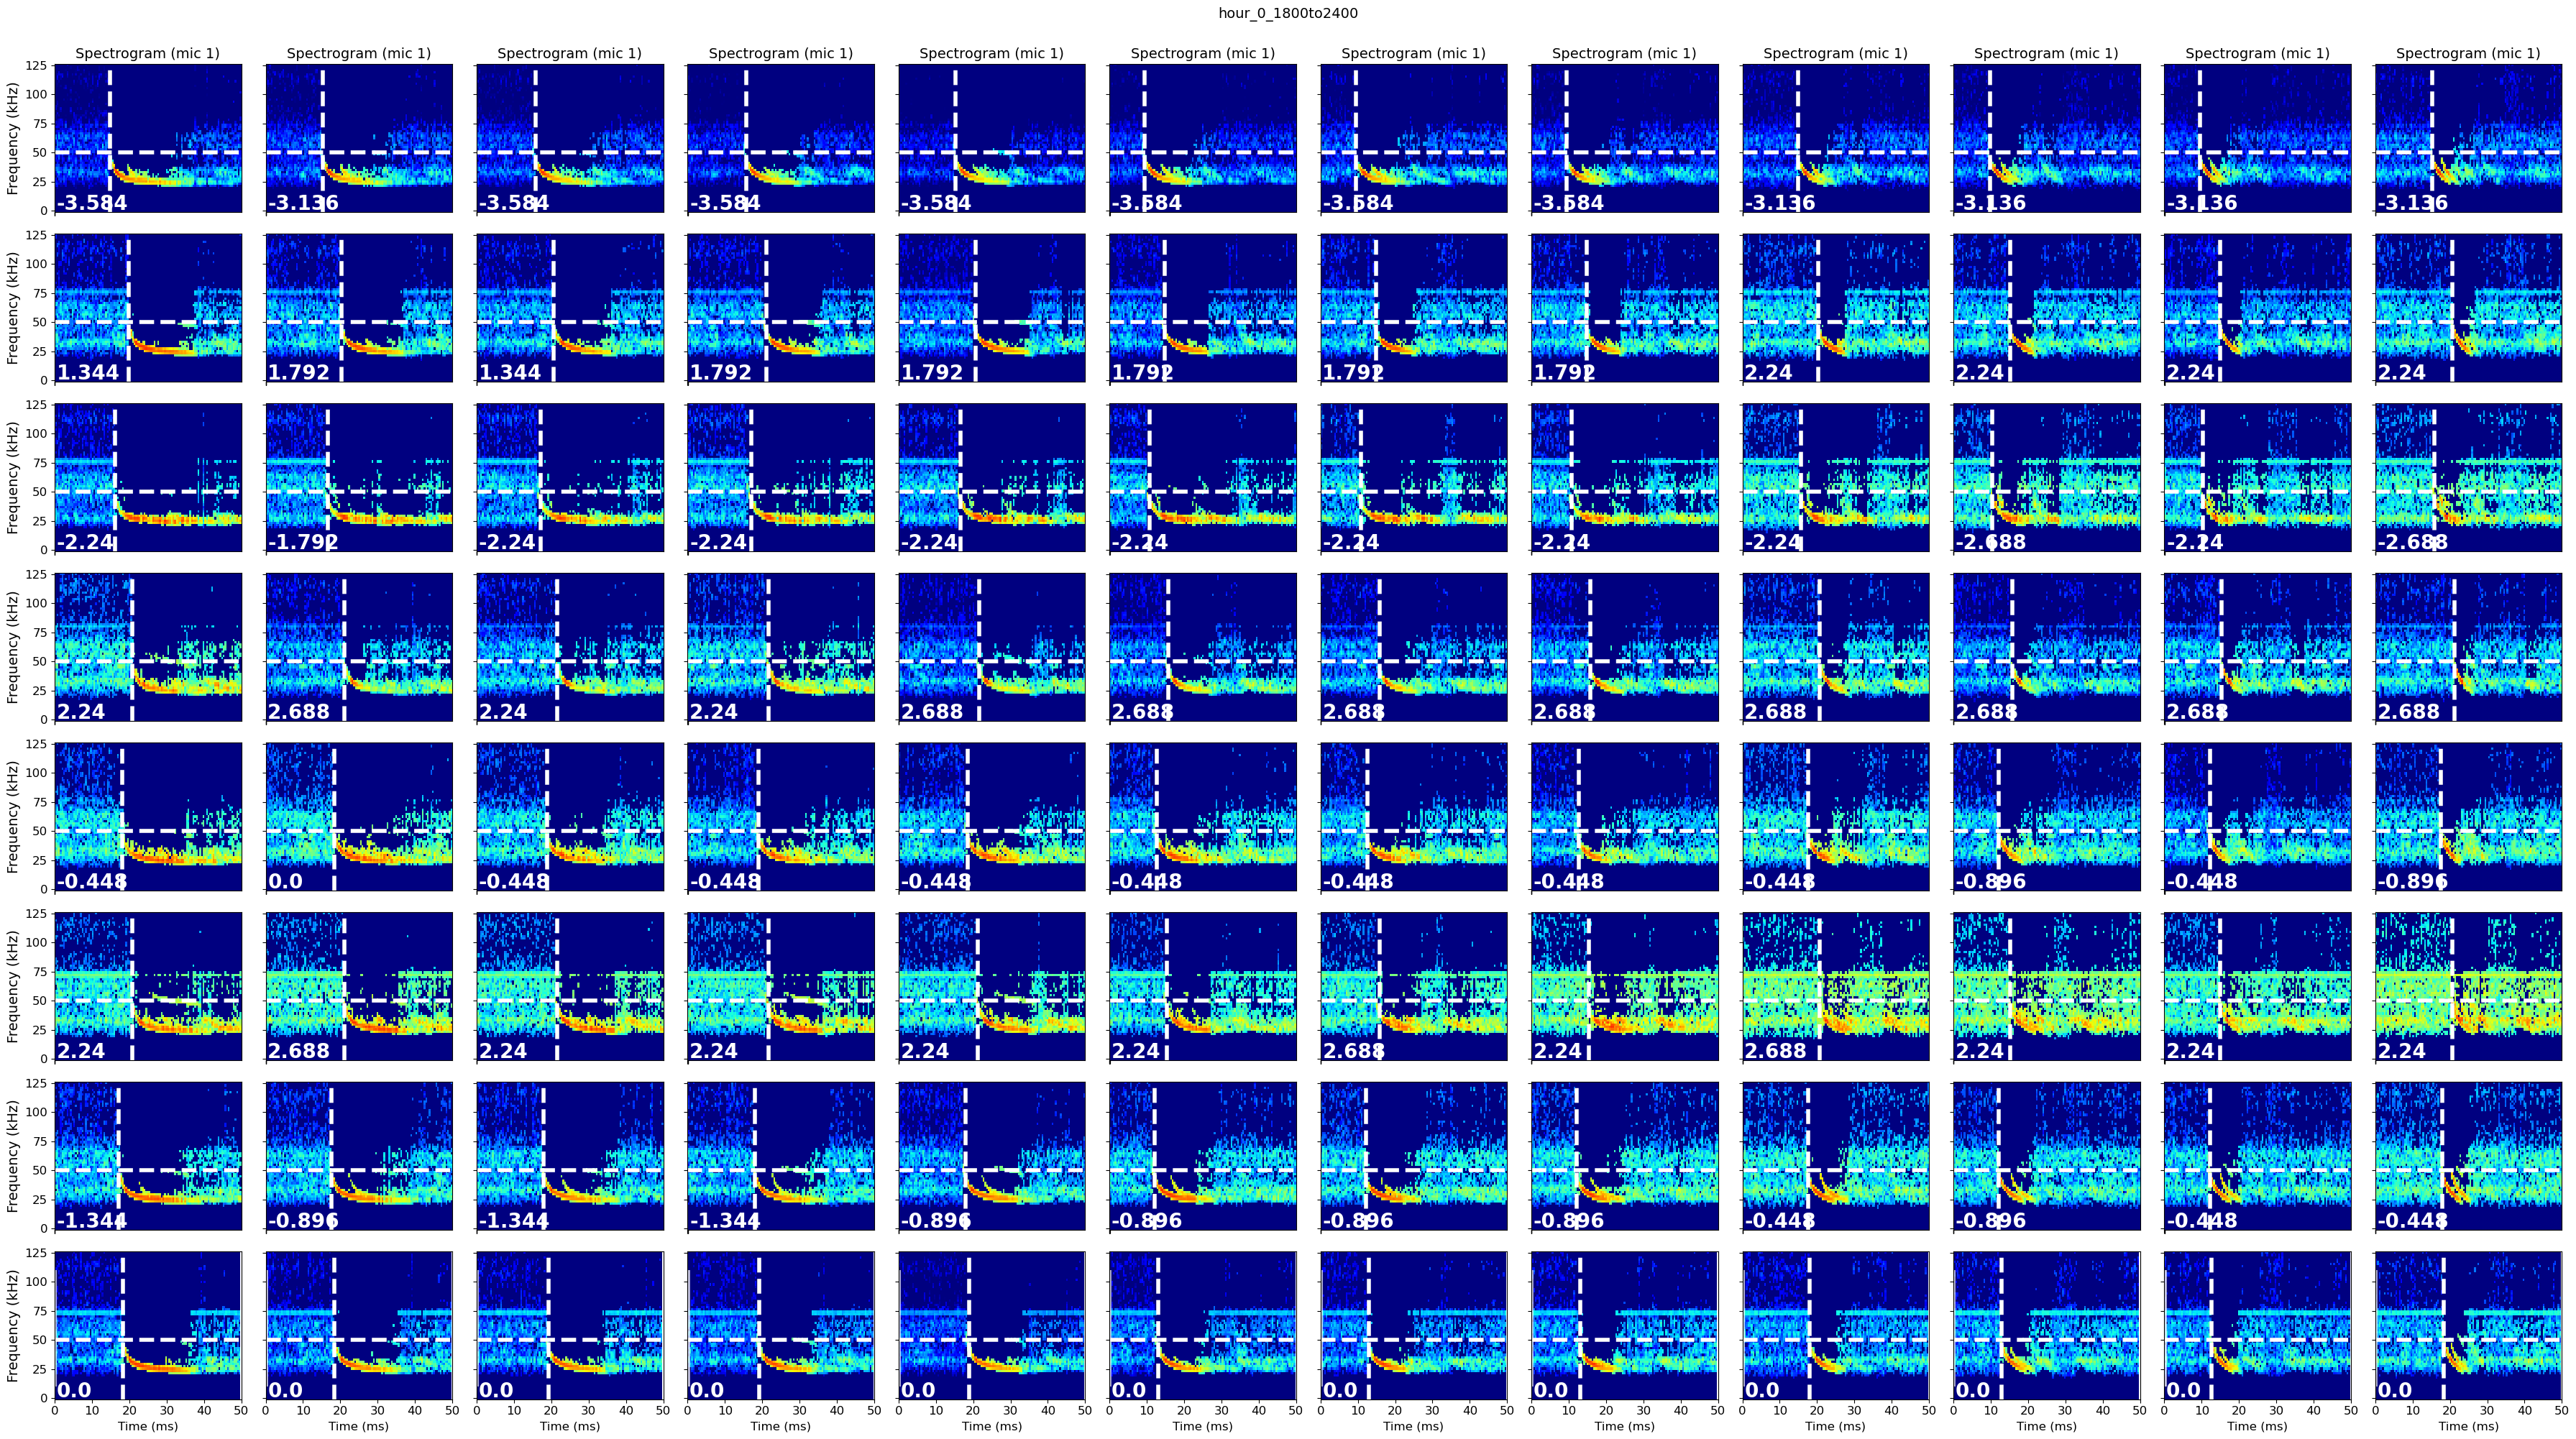

In [142]:
%matplotlib inline

example_t_delays_wrt_selected_channel = np.zeros((set_for_tdoa.shape[0], num_good_channels), dtype=np.float64)
channel_num = 0
plt.figure(figsize=(3*example_calls.shape[0], 2.5*num_good_channels))
plt.rcParams.update({'font.size': 12})
plt.suptitle(f'{HOUR_TAG}_{FILE_TIME_TAG}', y=1.0, fontsize=14)
for non_ref_call_i in range(num_good_channels):
    for det_num in range(example_calls.shape[0]):
        nonref_dets = example_calls[det_num]
        approx_call_dur = example_det_durs[det_num]
        # ref_call_of_det, ref_channel_num = index_reference_call_based_on_feature_to_maximize(example_calls, det_num, example_snr_facs)
        ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(example_calls, det_num, microphones_used, REF_CHANNEL)
        # ref_call_of_det, ref_channel_num = index_reference_call_based_on_feature_to_minimize(example_calls, det_num, example_snr_facs)
        ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)

        signal1 = ref_call_of_det
        signal2 = ref_mic_call_only

        channel_num+=1
        spec_features = dict()
        spec_features['NFFT'] = 128 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = -30
        spec_features['vmax'] = 5
        mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
        f, t, Sxx = scipy.signal.spectrogram(signal1, FS, detrend=False, nperseg=spec_features['NFFT'],
                                    nfft=spec_features['NFFT'], 
                                    window=mpl_specgram_window, mode='magnitude')
        cleaned_det, f, t = clean_section_to_remove_noise(signal1, np.max(Sxx), spec_features)
        cleaned_template, fc_f, fc_t = clean_section_to_remove_noise(signal2, np.max(Sxx), spec_features)
        max_ind = np.where(cleaned_det==np.max(cleaned_det))
        max_value_across_bins = Sxx[max_ind]
        peak_freq = f[max_ind[0]]
        peak_freq_time = t[max_ind[1]]

        det_Spec_lin = 10**(cleaned_det/10)
        tmpl_lin = 10**(cleaned_template/10)
        xcorr = scipy.signal.correlate2d(det_Spec_lin, tmpl_lin, mode='valid', boundary='fill')
        corr_vs_shift = xcorr[0]
        best_shift = int(np.argmax(corr_vs_shift)) 
        time_delay_in_samples = (spec_features['NFFT'] - (spec_features['NFFT']//8)) * best_shift
        auto_time_delay_in_seconds = time_delay_in_samples / FS

        signal1 = nonref_dets[non_ref_call_i, :]
        signal2 = ref_mic_call_only

        spec_features = dict()
        spec_features['NFFT'] = 128 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = -30
        spec_features['vmax'] = 5
        mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
        f, t, Sxx = scipy.signal.spectrogram(signal1, FS, detrend=False, nperseg=spec_features['NFFT'],
                                    nfft=spec_features['NFFT'], 
                                    window=mpl_specgram_window, mode='magnitude')
        cleaned_det, f, t = clean_section_to_remove_noise(signal1, np.max(Sxx), spec_features)
        cleaned_template, fc_f, fc_t = clean_section_to_remove_noise(signal2, np.max(Sxx), spec_features)
        max_ind = np.where(cleaned_det==np.max(cleaned_det))
        max_value_across_bins = Sxx[max_ind]
        peak_freq = f[max_ind[0]]
        peak_freq_time = t[max_ind[1]]

        det_Spec_lin = 10**(cleaned_det/10)
        tmpl_lin = 10**(cleaned_template/10)
        xcorr = scipy.signal.correlate2d(det_Spec_lin, tmpl_lin, mode='valid', boundary='fill')
        corr_vs_shift = xcorr[0]
        best_shift = int(np.argmax(corr_vs_shift)) 
        time_delay_in_samples = (spec_features['NFFT'] - (spec_features['NFFT']//8)) * best_shift
        time_delay_in_seconds = time_delay_in_samples / FS

        example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds - auto_time_delay_in_seconds

        plt.subplot(num_good_channels, example_calls.shape[0], channel_num)
        plt.rcParams.update({'font.size': 12})
        if non_ref_call_i==0:
            plt.title(f"Spectrogram (mic {microphones_used[non_ref_call_i]})", fontsize=14)
        plt.pcolormesh(t*1e3, f/1e3, cleaned_det, cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
        plt.text(x=0.5,y=0.85,s=f'{round(1000*(time_delay_in_seconds - auto_time_delay_in_seconds), 3)}',color='w',fontsize=20,fontweight='bold')
        plt.axvline(x=time_delay_in_seconds*1e3, linestyle='dashed', linewidth=4, color='w')
        plt.axhline(y=50, linestyle='dashed', linewidth=4, color='w')
        ax = plt.gca()
        if non_ref_call_i==ref_channel_num:
            rect_call = patches.Rectangle((time_delay_in_seconds, 10), len(ref_mic_call_only)/FS, (100), 
                            linewidth=4, edgecolor='white', facecolor='none', alpha=0.8)
            ax.add_patch(rect_call)
        if det_num==0:
            plt.yticks(np.linspace(0, FS/2000, 6).astype('int'))
            plt.ylabel("Frequency (kHz)", fontsize=14)
        else:
            plt.yticks(ticks=np.linspace(0, FS/2000, 6), labels=['']*6)
        if non_ref_call_i==(num_good_channels-1):
            plt.xticks((1000*np.linspace(0, SNR_CALC_LENGTH, 6)).astype(int), rotation=0)
            plt.xlabel("Time (ms)")    
        else:
            plt.xticks(ticks=np.linspace(0, SNR_CALC_LENGTH, 6), labels=['']*6)

plt.tight_layout()
plt.show()

In [143]:
example_t_delays_wrt_selected_channel * 1000

array([[-3.584,  1.344, -2.24 ,  2.24 , -0.448,  2.24 , -1.344,  0.   ],
       [-3.136,  1.792, -1.792,  2.688,  0.   ,  2.688, -0.896,  0.   ],
       [-3.584,  1.344, -2.24 ,  2.24 , -0.448,  2.24 , -1.344,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.24 , -0.448,  2.24 , -1.344,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.688, -0.448,  2.24 , -0.896,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.688, -0.448,  2.24 , -0.896,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.688, -0.448,  2.688, -0.896,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.688, -0.448,  2.24 , -0.896,  0.   ],
       [-3.136,  2.24 , -2.24 ,  2.688, -0.448,  2.688, -0.448,  0.   ],
       [-3.136,  2.24 , -2.688,  2.688, -0.896,  2.24 , -0.896,  0.   ],
       [-3.136,  2.24 , -2.24 ,  2.688, -0.448,  2.24 , -0.448,  0.   ],
       [-3.136,  2.24 , -2.688,  2.688, -0.896,  2.24 , -0.448,  0.   ]])

In [144]:
microphones_used[ind_of_selected_channel]

array([8])

In [145]:
t_delay_8_to_selected_channel = example_t_delays_wrt_selected_channel[:,ind_of_selected_channel]
time_delay_mics_to_selected_ref_channel = (example_t_delays_wrt_selected_channel[:]) - (t_delay_8_to_selected_channel.reshape((len(t_delay_8_to_selected_channel), 1)))
time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, ind_of_selected_channel, axis=1)
example_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * C)
time_delay_mics_to_selected_ref_channel * 1000

array([[-3.584,  1.344, -2.24 ,  2.24 , -0.448,  2.24 , -1.344,  0.   ],
       [-3.136,  1.792, -1.792,  2.688,  0.   ,  2.688, -0.896,  0.   ],
       [-3.584,  1.344, -2.24 ,  2.24 , -0.448,  2.24 , -1.344,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.24 , -0.448,  2.24 , -1.344,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.688, -0.448,  2.24 , -0.896,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.688, -0.448,  2.24 , -0.896,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.688, -0.448,  2.688, -0.896,  0.   ],
       [-3.584,  1.792, -2.24 ,  2.688, -0.448,  2.24 , -0.896,  0.   ],
       [-3.136,  2.24 , -2.24 ,  2.688, -0.448,  2.688, -0.448,  0.   ],
       [-3.136,  2.24 , -2.688,  2.688, -0.896,  2.24 , -0.896,  0.   ],
       [-3.136,  2.24 , -2.24 ,  2.688, -0.448,  2.24 , -0.448,  0.   ],
       [-3.136,  2.24 , -2.688,  2.688, -0.896,  2.24 , -0.448,  0.   ]])

In [146]:
A_locs_mat_tdoa_inches

array([[-17.7   , -37.5   ,  31.6875],
       [-17.7   ,  37.5   ,  31.6875],
       [-17.7   , -37.5   ,   0.    ],
       [-17.7   ,  37.5   ,   0.    ],
       [-17.7   , -21.    , -29.125 ],
       [-17.7   ,  21.    , -29.125 ],
       [  0.    ,   0.    ,  31.6875]])

In [147]:
A_locs_mat_tdoa_meters

array([[-0.44958  , -0.9525   ,  0.8048625],
       [-0.44958  ,  0.9525   ,  0.8048625],
       [-0.44958  , -0.9525   ,  0.       ],
       [-0.44958  ,  0.9525   ,  0.       ],
       [-0.44958  , -0.5334   , -0.739775 ],
       [-0.44958  ,  0.5334   , -0.739775 ],
       [ 0.       ,  0.       ,  0.8048625]])

In [148]:
example_d_mics_to_ref[0, :].reshape((num_nonref_channels, 1))

array([[-1.229312],
       [ 0.460992],
       [-0.76832 ],
       [ 0.76832 ],
       [-0.153664],
       [ 0.76832 ],
       [-0.460992]])

In [149]:
source_locs = np.zeros((4, example_d_mics_to_ref.shape[0]), dtype=np.float64)
for i in range(example_d_mics_to_ref.shape[0]):
    dm0_column = example_d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))
    A_mat = np.hstack(((0-A_locs_mat_tdoa_meters), dm0_column))
        
    xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))

    wm0 = ((dm0_column**2) - (xm**2) - (ym**2) - (zm**2))/2

    xs, residuals, rank, sing_vals = np.linalg.lstsq(A_mat, wm0, rcond=None)

    source_locs[:,i] = xs.reshape((1,4))
source_locs

array([[-0.79605504,  0.00817021, -0.79605504, -0.74396141, -0.5678122 ,
        -0.5678122 , -0.5373962 , -0.5678122 , -0.35706424, -0.7218627 ,
        -0.12051171, -0.42413397],
       [-0.06783844, -2.17505574, -0.06783844, -0.55178404, -1.65907365,
        -1.65907365, -0.81074548, -1.65907365, -1.28626804,  0.69620052,
        -3.06853189, -3.51904413],
       [ 0.20279256,  1.27402336,  0.20279256,  0.39838313,  0.83886086,
         0.83886086,  0.52690197,  0.83886086,  0.5824499 , -0.06241046,
         1.04460214,  0.99543689],
       [-0.21095598, -2.53838564, -0.21095598, -0.72877151, -1.87389597,
        -1.87389597, -0.91347583, -1.87389597, -1.35162675,  0.68152139,
        -3.33756328, -3.64878367]])

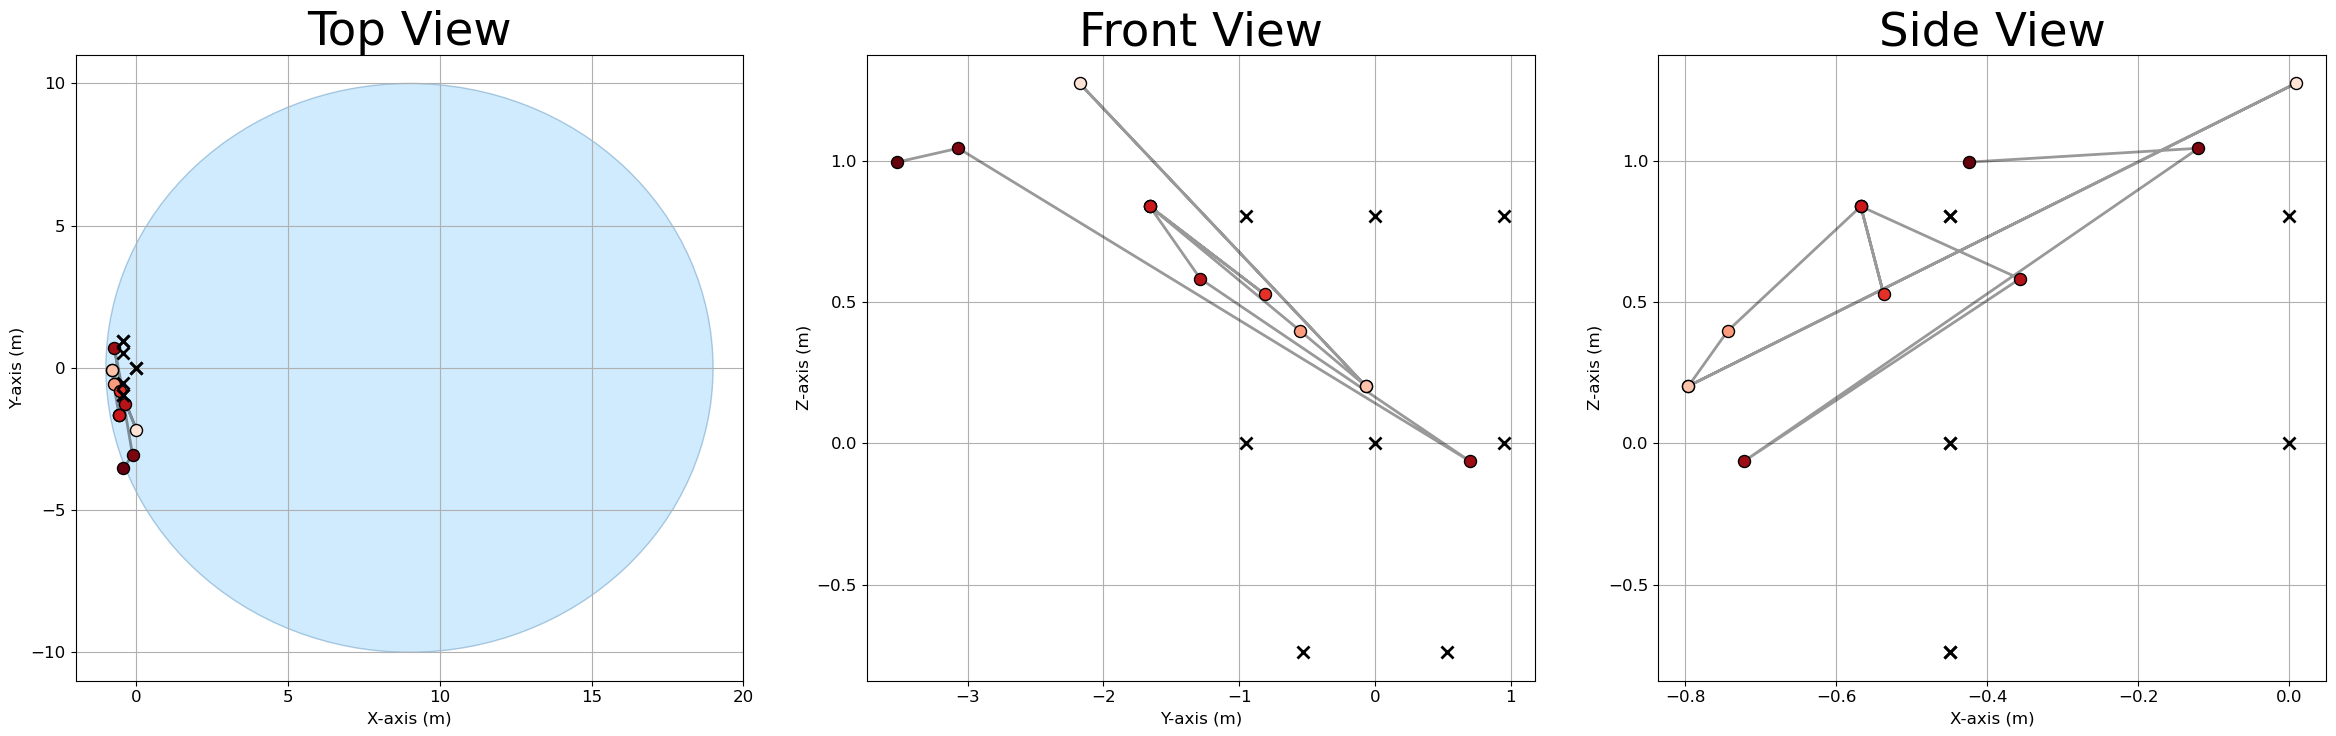

In [150]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':28})
plot_three_plane_trajectories(ax1, ax2, ax3, set_for_tdoa, source_locs, source_locs, A_locs_mat_tdoa_meters, 1)

ax1.scatter(x=0, y=0, s=POINT_SIZE, zorder=3, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')
ax2.scatter(x=0, y=0, s=POINT_SIZE, zorder=3, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')
ax3.scatter(x=0, y=0, s=POINT_SIZE, zorder=3, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')

ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')
circle_center = (9, 0.0)   # (x, y) coordinates in metres  ← change here
circle_radius = 10.0          # metres                         ← and here

circle = Circle(
    circle_center,
    circle_radius,
    facecolor='lightskyblue',    # light-blue fill
    edgecolor='steelblue',       # slightly darker edge
    alpha=0.4,                   # 40 % opacity so trajectories stay visible
    zorder=1
)
ax1.add_patch(circle)

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

In [151]:
'

SyntaxError: EOL while scanning string literal (544193499.py, line 1)

In [ ]:
delta_source_loc = source_locs[:3,1:] - source_locs[:3,:-1]
delta_source_loc

array([[ 0.46586005,  0.38276755, -0.02331107,  0.02066126, -0.18797915,
        -0.12874844, -0.09141464, -0.10793558, -0.07738605, -0.17566786,
         0.2230146 ],
       [ 0.0811505 , -2.96277668,  1.58085311, -1.27905945,  1.28667945,
        -0.16531774,  0.01359374, -0.08746244, -2.15159941,  1.1320467 ,
         0.21983564],
       [-0.12795222,  1.10749032, -0.84796597,  0.4638105 , -0.88483353,
        -0.20318003, -0.46876833, -0.34338938,  0.31054612, -0.76950882,
        -0.38090895]])

In [ ]:
delta_t = (set_for_tdoa['start_time'].shift(-1) - set_for_tdoa['start_time'])[:-1]
measured_velocity = np.sqrt(np.sum((delta_source_loc**2),axis=0)) / delta_t
measured_velocity

0      3.655824
1     23.256042
2     13.095400
3     10.630571
4     11.915418
5      2.538002
6      4.507471
7      4.517400
8     25.293858
9     18.904768
10     9.303912
Name: start_time, dtype: float64

In [ ]:
SPEED_THRESHOLD = 10
measured_velocity[measured_velocity<SPEED_THRESHOLD].values

array([3.65582351, 2.53800215, 4.50747145, 4.5174003 , 9.30391203])

In [ ]:
good_source_locs = source_locs[:,1:][:,(measured_velocity.values<SPEED_THRESHOLD)]
good_set_for_tdoa = set_for_tdoa.iloc[1:].loc[(measured_velocity.values<SPEED_THRESHOLD)]
good_source_locs

array([[ 1.63485695e-01,  2.26875845e-01,  1.35461208e-01,
         2.75256282e-02, -2.51367079e-03],
       [-9.50555949e+00, -1.10451808e+01, -1.10315871e+01,
        -1.11190495e+01, -1.19187666e+01],
       [ 5.12170560e+00,  4.75702688e+00,  4.28825856e+00,
         3.94486918e+00,  3.10499753e+00],
       [-1.08831722e+01, -1.20729133e+01, -1.18848073e+01,
        -1.18275819e+01, -1.23199685e+01]])

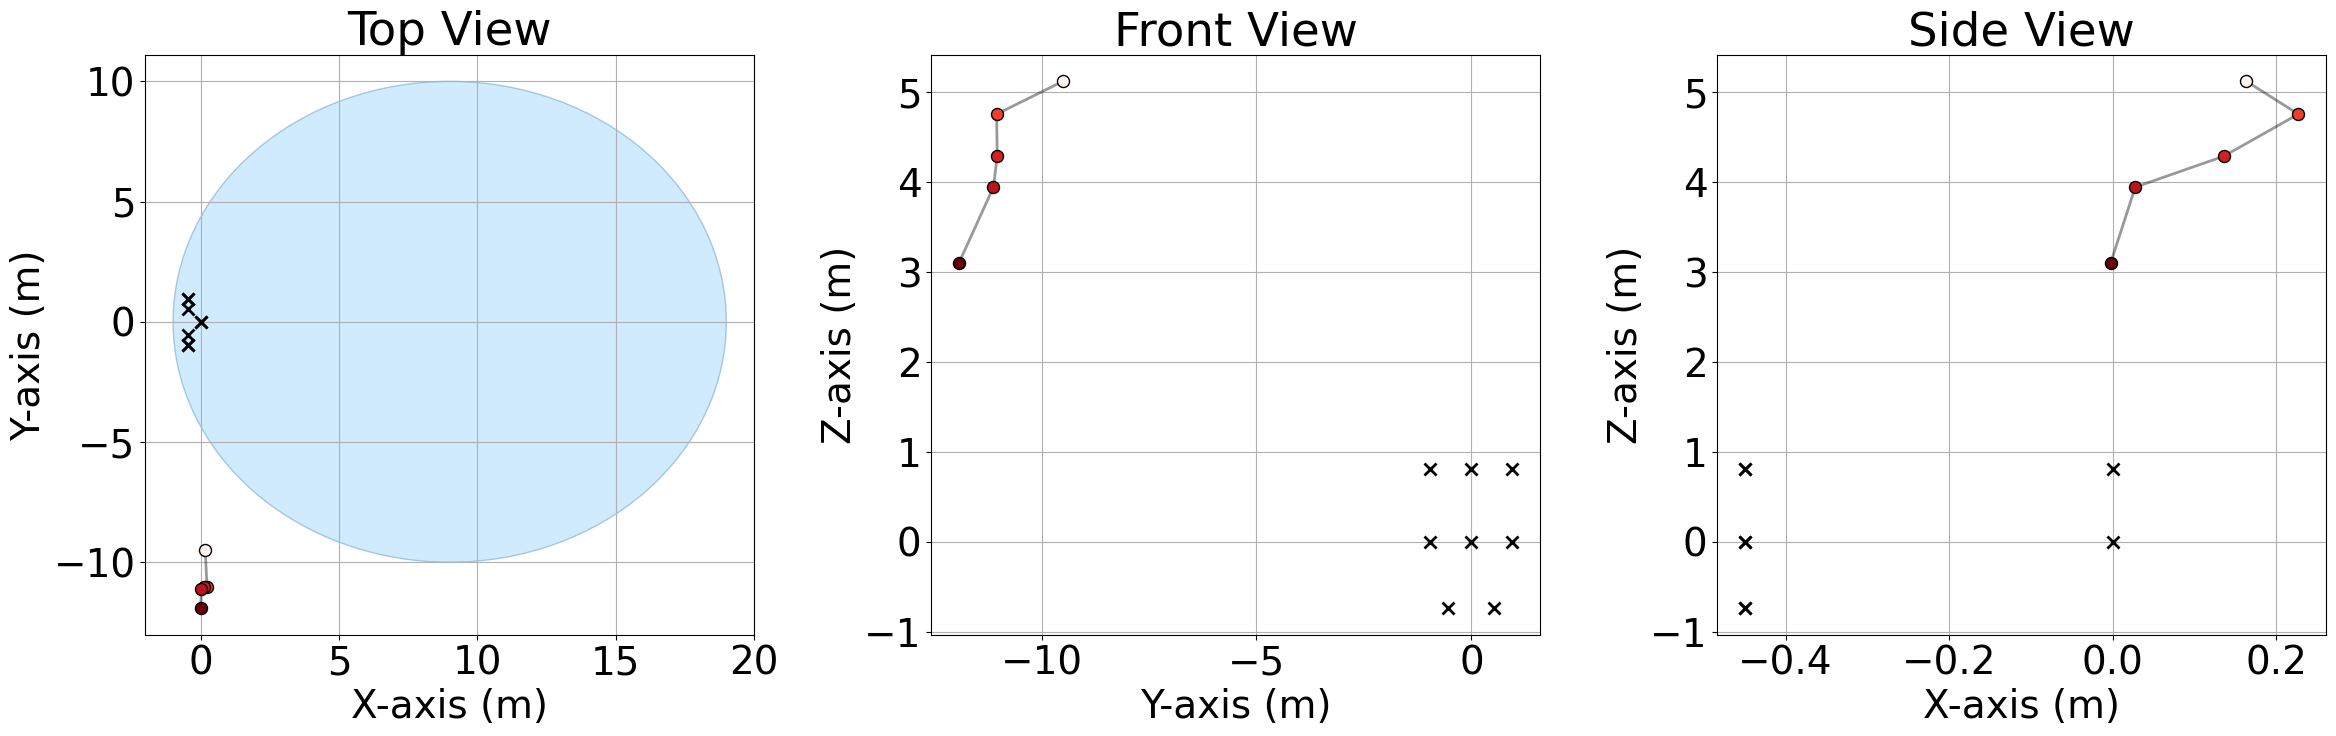

In [ ]:
%matplotlib inline

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':28})
plot_three_plane_trajectories(ax1, ax2, ax3, good_set_for_tdoa, good_source_locs, good_source_locs, A_locs_mat_tdoa_meters, 1)

ax1.scatter(x=0, y=0, s=POINT_SIZE, zorder=3, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')
ax2.scatter(x=0, y=0, s=POINT_SIZE, zorder=3, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')
ax3.scatter(x=0, y=0, s=POINT_SIZE, zorder=3, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')

ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')
circle_center = (9, 0.0)   # (x, y) coordinates in metres  ← change here
circle_radius = 10.0          # metres                         ← and here

circle = Circle(
    circle_center,
    circle_radius,
    facecolor='lightskyblue',    # light-blue fill
    edgecolor='steelblue',       # slightly darker edge
    alpha=0.4,                   # 40 % opacity so trajectories stay visible
    zorder=1
)
ax1.add_patch(circle)

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets

In [ ]:
%matplotlib widget

def update(frame):
    fig = plt.figure(figsize=(10, 10))
    plt.rcParams.update({'font.size': 12})
    ax = fig.add_subplot(projection='3d')

    norm = plt.Normalize(vmin=min(good_set_for_tdoa['start_time']), vmax=max(good_set_for_tdoa['start_time']))
    for i in range(frame):
        det = good_set_for_tdoa.iloc[i]
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(det['start_time']))
         # Redraw the scatter points up to the current frame
        ax.scatter(
            good_source_locs[0, i],
            good_source_locs[1, i],
            good_source_locs[2, i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
    
   
    
    # Redraw the trajectory line up to the current frame
    ax.plot(
        good_source_locs[0, :frame],
        good_source_locs[1, :frame],
        good_source_locs[2, :frame],
        color='k',
        alpha=0.4,
    )

    ax.scatter(xs=A_locs_mat_tdoa_meters[:, 0], ys=A_locs_mat_tdoa_meters[:, 1], zs=A_locs_mat_tdoa_meters[:, 2], facecolor='yellow', 
               edgecolor='k', alpha=1, label='microphone positions')
    ax.scatter(xs=0, ys=0, zs=0, facecolor='yellow', edgecolor='k', alpha=1)
    
    # Restore axis labels and title after clearing
    ax.set_xlabel('X Coordinate (m)')
    ax.set_ylabel('Y Coordinate (m)')
    ax.set_zlabel('Z Coordinate (m)')
    ax.set_title('Trajectory 1 of bat recorded at Telephone Field')
    ax.set_xlim([-20, 20])
    ax.set_ylim([-20, 20])
    ax.set_zlim([-2, 10])

    ax.legend()

    plt.show()

In [ ]:
start_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=good_source_locs.shape[1],
    step=1,
    description="Start (s)",
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width="400px")
)

widgets.interactive(update, frame=start_slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Start (s)', layout=Layout(width…

In [ ]:
GRID_SIZE = 2000
CIRCLE_RADIUS = 400
SOUND_SPEED_WATER = 1500
TIME_RECEIVED_AT_RN = 1
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']

ValueError: operands could not be broadcast together with shapes (40000,) (3,) 

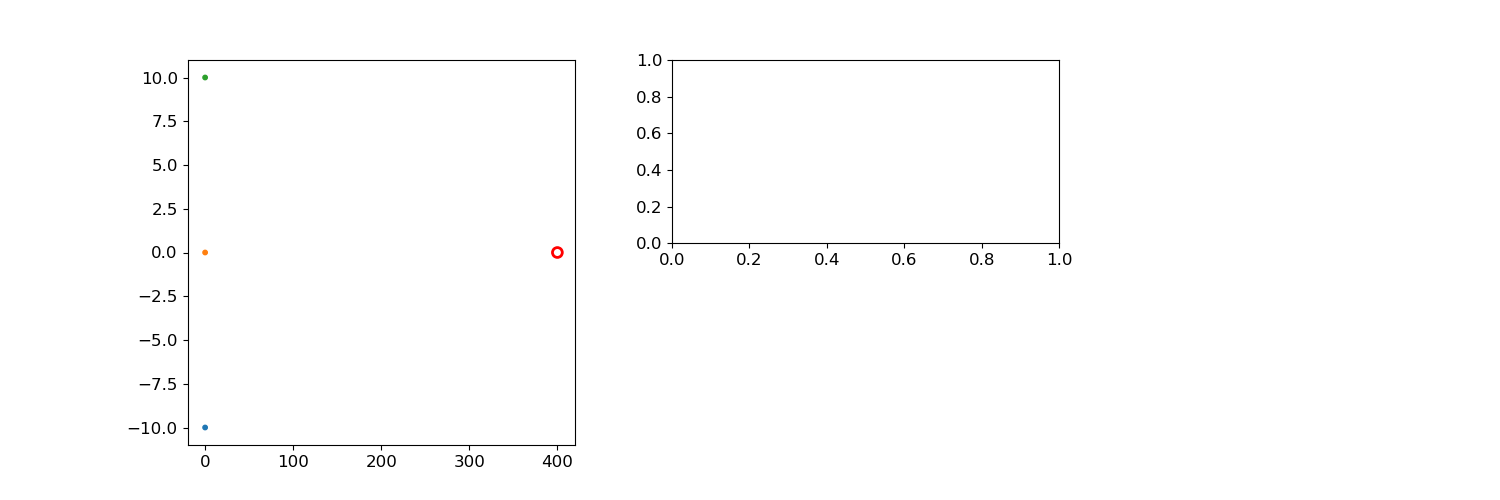

In [ ]:
angle_deg = 0
N = 3
frequency = 200
spacing = 10

rN_x = np.zeros(N)
rN_y = np.linspace(-spacing * (N - 1) / 2, spacing * (N - 1) / 2, N)
if N==1:
    trace_offsets = np.array([0])
else:
    trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

sampling_rate = min(10000, int(1000*(10**(np.floor(np.log10(frequency))))))
t = np.linspace(0, 4, sampling_rate*4)
signal = scipy.signal.unit_impulse(t.size, idx=100) * 1000
plot_duration = 2*(10**(-np.floor(np.log10(frequency))))
signal_duration = 2.5*(10**(-np.floor(np.log10(frequency))))

angle_degrees = np.arange(-90, 90)
angle_idx = np.where(np.isclose(angle_degrees, angle_deg, atol=1e-2))[0][0]
angle_radians = np.radians(angle_degrees)
circle_x_arr = CIRCLE_RADIUS * np.cos(angle_radians)
circle_y_arr = CIRCLE_RADIUS * np.sin(angle_radians)
circle_x = circle_x_arr[angle_idx]
circle_y = circle_y_arr[angle_idx]

dist_from_source_to_r_n_arr = np.sqrt((circle_x_arr[None, :] - rN_x[:, None]) ** 2 + (circle_y_arr[None, :] - rN_y[:, None]) ** 2)

time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_WATER
receive_signaln_for_degrees = signal[:, None, None]
signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
chunk_of_received_signaln_in_window_degrees = np.take_along_axis(receive_signaln_for_degrees, rn_indices, axis=0)

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.3) 
gs_signals = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[2,1], subplot_spec=gs[0, 1], hspace=0.8)
map_ax = plt.subplot(gs[0, 0])
map_ax.scatter(circle_x, circle_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")

received_ax = plt.subplot(gs_signals[0])
map_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
received_ax.plot(1000*(t), signal+trace_offsets)
marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax.set_xlabel("X (meters)")
map_ax.set_ylabel("Y (meters)")
map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
map_ax.legend(handles=marker_handles, ncol=3, loc='upper right')

received_ax.set_xlabel("Time (ms)")
received_ax.set_ylabel("Amplitude")
received_ax.set_title("Received voltage signals")
received_ax.grid(which='both')
received_ax.set_yticks([], [])
received_ax.set_xlim(-int(signal_duration * sampling_rate), int(signal_duration * sampling_rate))
received_ax.set_ylim(-1e-4, 1e-4)
received_ax.legend(handles=line_handles, ncol=3, loc='upper right')

summed_signal_degrees = np.sum(chunk_of_received_signaln_in_window_degrees, axis=1)
vrms_summed = np.sqrt(np.mean(np.square(summed_signal_degrees), axis=0))
vrms_summed_dB = 20*np.log10(vrms_summed)
vrms_summed_dB_norm = vrms_summed_dB - vrms_summed_dB.max()

summed_signal = summed_signal_degrees[:, angle_idx]
vrms_summed_fixed = vrms_summed[angle_idx]
vrms_summed_fixed_dB = 20*np.log10(vrms_summed_fixed)
vrms_summed_fixed_dB_norm = vrms_summed_fixed_dB - vrms_summed_dB.max()

summed_ax = plt.subplot(gs_signals[1])
summed_ax.plot(1000*(signal_duration_samples / sampling_rate), summed_signal, 'k')
summed_ax.set_xlabel("Time (ms)")
summed_ax.set_ylabel("Amplitude")
summed_ax.set_title("Summed voltage signal")
summed_ax.set_yticks([], [])
summed_ax.grid(which='both')
summed_ax.set_xlim(0, 1000*plot_duration)
summed_ax.set_ylim(-5e-5, 5e-5)

plt.show()

In [ ]:
GRID_SIZE = 2000
CIRCLE_RADIUS = 400
SOUND_SPEED_WATER = 1500
TIME_RECEIVED_AT_RN = 1
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']

def simulate_N_receivers(angle_deg, frequency, N, spacing):
    rN_x = np.zeros(N)
    rN_y = np.linspace(-spacing * (N - 1) / 2, spacing * (N - 1) / 2, N)
    if N==1:
        trace_offsets = np.array([0])
    else:
        trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

    sampling_rate = min(10000, int(1000*(10**(np.floor(np.log10(frequency))))))
    t = np.linspace(0, 4, sampling_rate*4)
    signal = np.sin(t*2*np.pi*frequency)
    plot_duration = 2*(10**(-np.floor(np.log10(frequency))))
    signal_duration = 2.5*(10**(-np.floor(np.log10(frequency))))

    angle_degrees = np.arange(-90, 90)
    angle_idx = np.where(np.isclose(angle_degrees, angle_deg, atol=1e-2))[0][0]
    angle_radians = np.radians(angle_degrees)
    circle_x_arr = CIRCLE_RADIUS * np.cos(angle_radians)
    circle_y_arr = CIRCLE_RADIUS * np.sin(angle_radians)
    circle_x = circle_x_arr[angle_idx]
    circle_y = circle_y_arr[angle_idx]

    dist_from_source_to_r_n_arr = np.sqrt((circle_x_arr[None, :] - rN_x[:, None]) ** 2 + (circle_y_arr[None, :] - rN_y[:, None]) ** 2)

    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_WATER
    receive_signaln_for_degrees = signal[:, None, None] / (dist_from_source_to_r_n_arr[None, :, :] ** 2)
    signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
    rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_degrees = np.take_along_axis(receive_signaln_for_degrees, rn_indices, axis=0)

    fig = plt.figure(figsize=(15, 5))
    gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.3) 
    gs_signals = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[2,1], subplot_spec=gs[0, 1], hspace=0.8)
    map_ax = plt.subplot(gs[0, 0])
    map_ax.scatter(circle_x, circle_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")

    received_ax = plt.subplot(gs_signals[0])
    map_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    received_ax.plot(1000*(np.tile(signal_duration_samples / sampling_rate, (N, 1)).T), chunk_of_received_signaln_in_window_degrees[:,:,angle_idx]+trace_offsets)
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=3, loc='upper right')

    received_ax.set_xlabel("Time (ms)")
    received_ax.set_ylabel("Amplitude")
    received_ax.set_title("Received voltage signals")
    received_ax.grid(which='both')
    received_ax.set_yticks([], [])
    received_ax.set_xlim(0, 1000*(plot_duration))
    received_ax.set_ylim(-1e-4, 1e-4)
    received_ax.legend(handles=line_handles, ncol=3, loc='upper right')

    summed_signal_degrees = np.sum(chunk_of_received_signaln_in_window_degrees, axis=1)
    vrms_summed = np.sqrt(np.mean(np.square(summed_signal_degrees), axis=0))
    vrms_summed_dB = 20*np.log10(vrms_summed)
    vrms_summed_dB_norm = vrms_summed_dB - vrms_summed_dB.max()

    summed_signal = summed_signal_degrees[:, angle_idx]
    vrms_summed_fixed = vrms_summed[angle_idx]
    vrms_summed_fixed_dB = 20*np.log10(vrms_summed_fixed)
    vrms_summed_fixed_dB_norm = vrms_summed_fixed_dB - vrms_summed_dB.max()

    summed_ax = plt.subplot(gs_signals[1])
    summed_ax.plot(1000*(signal_duration_samples / sampling_rate), summed_signal, 'k')
    summed_ax.set_xlabel("Time (ms)")
    summed_ax.set_ylabel("Amplitude")
    summed_ax.set_title("Summed voltage signal")
    summed_ax.set_yticks([], [])
    summed_ax.grid(which='both')
    summed_ax.set_xlim(0, 1000*plot_duration)
    summed_ax.set_ylim(-5e-5, 5e-5)

    gs_beam_pattern = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[0, 2], hspace=0.8)
    beam_pattern_ax = plt.subplot(gs_beam_pattern[0])
    beam_pattern_ax.set_title(f'Beam pattern')
    beam_pattern_ax.plot(vrms_summed_dB_norm, angle_degrees, color='k')
    beam_pattern_ax.scatter(vrms_summed_fixed_dB_norm, angle_deg, edgecolors='red', facecolors='w', linewidth=2, zorder=2)
    beam_pattern_ax.set_xlim(-40, 1)
    beam_pattern_ax.grid(which='both')
    beam_pattern_ax.set_xlabel(r'dB$V_{rms}$ (dB)')
    beam_pattern_ax.set_ylabel('Angle (°)')

    plt.show()


angle_slider = widgets.IntSlider(
    value=0, min=-90, max=90, step=1, description="Angle (°)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

frequency_slider = widgets.IntSlider(
    value=10, min=1, max=2e2, step=1, description="Frequency (Hz)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

N_slider = widgets.IntSlider(
    value=0, min=1, max=5, step=1, description="# receivers", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="300px")
)

spacing_slider = widgets.IntSlider(
    value=40, min=10, max=100, step=1, description="Spacing (m)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, angle_deg=angle_slider, frequency=frequency_slider, N=N_slider, spacing=spacing_slider)
display(interactive_plot)

interactive(children=(IntSlider(value=0, description='Angle (°)', layout=Layout(width='1000px'), max=90, min=-…